In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Import the data as pandas from xlsx file
data = pd.read_excel("C:\\Users\\chuab\\Downloads\\diann_jurkats_output.xlsx")


data_raw = data.copy()# Keep a copy of raw data for comparative QC plots# Keep a copy of raw data for comparative QC plots

# Data cleanup

In [3]:
columns_to_remove = [
    'Channel', 'Decoy', 'IM', 'iIM', 'Predicted.IM', 'Predicted.iIM', 'PG.TopN', 'Genes.TopN','Translated.Q.Value',
]

data_cleaned = data.drop(columns=columns_to_remove)

In [4]:
# print cleaned data columns
print(data_cleaned.columns)

Index(['Run.Index', 'Run', 'Precursor.Id', 'Modified.Sequence',
       'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Lib.Index',
       'Proteotypic', 'Precursor.Mz', 'Protein.Ids', 'Protein.Group',
       'Protein.Names', 'Genes', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT',
       'Precursor.Quantity', 'Precursor.Normalised', 'Ms1.Area',
       'Ms1.Normalised', 'Ms1.Apex.Area', 'Ms1.Apex.Mz.Delta',
       'Normalisation.Factor', 'Quantity.Quality', 'Empirical.Quality',
       'Normalisation.Noise', 'Ms1.Profile.Corr', 'Evidence', 'Mass.Evidence',
       'Channel.Evidence', 'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After',
       'RT.Start', 'RT.Stop', 'FWHM', 'PG.MaxLFQ', 'Genes.MaxLFQ',
       'Genes.MaxLFQ.Unique', 'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality',
       'Genes.MaxLFQ.Unique.Quality', 'Q.Value', 'PEP', 'Global.Q.Value',
       'Lib.Q.Value', 'Peptidoform.Q.Value', 'Global.Peptidoform.Q.Value',
       'Lib.Peptidoform.Q.Value', 'PTM.Site.Confidence',
       'S

In [5]:
# Step 1: Check for missing values in key columns
# Missing values in identification columns like 'Protein.Ids', 'Genes', or 'Modified.Sequence' can indicate incomplete data.
# We should inspect and decide whether to drop or impute them.
missing_values = data_cleaned.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Genes               167
Protein.Sites    254866
dtype: int64


In [6]:
# Step 2: Filter based on quality scores
# In proteomics, Q.Value and PEP are key quality metrics. Typically, filter for Q.Value < 0.01 and PEP < 0.05 to retain high-confidence identifications.
# Also, check Global.Q.Value if available.
data_cleaned = data_cleaned[(data_cleaned['Q.Value'] < 0.01) & (data_cleaned['PEP'] < 0.05)]
print(f"Data shape after quality filtering: {data_cleaned.shape}")

Data shape after quality filtering: (772517, 64)


In [7]:
# Step 3: Remove rows with missing essential identifiers
# Rows without 'Protein.Ids' or 'Genes' might not be useful for downstream analysis.
data_cleaned = data_cleaned.dropna(subset=['Protein.Ids', 'Genes'])
print(f"Data shape after removing missing identifiers: {data_cleaned.shape}")
# Create QC table: high-confidence identifications after FDR filtering, no dedup
qc_table = data_cleaned.copy()


Data shape after removing missing identifiers: (772361, 64)


In [8]:
# Step 4: Handle duplicates
# Duplicates might occur based on 'Modified.Sequence' and 'Protein.Ids'. Keep the one with the best Q.Value.
# Sort by Q.Value ascending (lower is better) and drop duplicates keeping the first.
data_cleaned = data_cleaned.sort_values('Q.Value').drop_duplicates(subset=['Modified.Sequence', 'Protein.Ids'], keep='first')
print(f"Data shape after removing duplicates: {data_cleaned.shape}")
# Create analysis table: deduped for downstream quantitative and statistical analyses
analysis_table = data_cleaned.copy()

Data shape after removing duplicates: (61438, 64)


In [9]:
# Step 5: Ensure correct data types
# Convert numeric columns to appropriate types if not already.
# For example, quantities and masses should be float, charges int, etc.
numeric_cols = ['Precursor.Charge', 'Precursor.Mz', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT', 
                'Precursor.Quantity', 'Precursor.Normalised', 'Ms1.Area', 'Ms1.Normalised', 
                'Ms1.Apex.Area', 'Ms1.Apex.Mz.Delta', 'Normalisation.Factor', 'Quantity.Quality', 
                'Empirical.Quality', 'Normalisation.Noise', 'Ms1.Profile.Corr', 'Evidence', 
                'Mass.Evidence', 'Channel.Evidence', 'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After', 
                'RT.Start', 'RT.Stop', 'FWHM', 'PG.MaxLFQ', 'Genes.MaxLFQ', 'Genes.MaxLFQ.Unique', 
                'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality', 'Genes.MaxLFQ.Unique.Quality', 
                'Q.Value', 'PEP', 'Global.Q.Value', 'Lib.Q.Value', 'Peptidoform.Q.Value', 
                'Global.Peptidoform.Q.Value', 'Lib.Peptidoform.Q.Value', 'Channel.Q.Value', 
                'PG.Q.Value', 'PG.PEP', 'GG.Q.Value', 'Protein.Q.Value', 'Global.PG.Q.Value', 
                'Lib.PG.Q.Value', 'Best.Fr.Mz', 'Best.Fr.Mz.Delta']
data_cleaned[numeric_cols] = data_cleaned[numeric_cols].apply(pd.to_numeric, errors='coerce')
print("Data types ensured for numeric columns.")

Data types ensured for numeric columns.


In [10]:
data_cleaned['RT'].describe()

count    61438.000000
mean        10.093965
std          3.934339
min          0.450259
25%          7.201215
50%         10.062943
75%         13.181698
max         17.057131
Name: RT, dtype: float64

In [11]:
# Step 6: Handle outliers or invalid values
# For quantities, negative values might be invalid. Set them to NaN or remove.
# Also, check for RT values within expected range (e.g., 0-120 min).
data_cleaned.loc[data_cleaned['Precursor.Quantity'] < 0, 'Precursor.Quantity'] = np.nan
data_cleaned.loc[data_cleaned['Ms1.Area'] < 0, 'Ms1.Area'] = np.nan
# Filter RT between 0 and 120
data_cleaned = data_cleaned[(data_cleaned['RT'] >= 0) & (data_cleaned['RT'] <= 120)]
print(f"Data shape after handling outliers: {data_cleaned.shape}")

Data shape after handling outliers: (61438, 64)


Final QC table shape: (640583, 64)
Final analysis table shape: (50367, 64)
          Run.Index  Precursor.Charge  Precursor.Lib.Index   Proteotypic  \
count  50367.000000      50367.000000         50367.000000  50367.000000   
mean      71.435702          2.563087         40451.737606      0.962475   
std        3.516091          0.496009         23872.450278      0.190045   
min       64.000000          2.000000             1.000000      0.000000   
25%       71.000000          2.000000         19809.500000      1.000000   
50%       72.000000          3.000000         39800.000000      1.000000   
75%       72.000000          3.000000         60469.500000      1.000000   
max       79.000000          3.000000         82794.000000      1.000000   

       Precursor.Mz            RT           iRT  Predicted.RT  Predicted.iRT  \
count  50367.000000  50367.000000  50367.000000  50367.000000   50367.000000   
mean     734.843474     10.175731     38.919815     10.179385      38.927648   


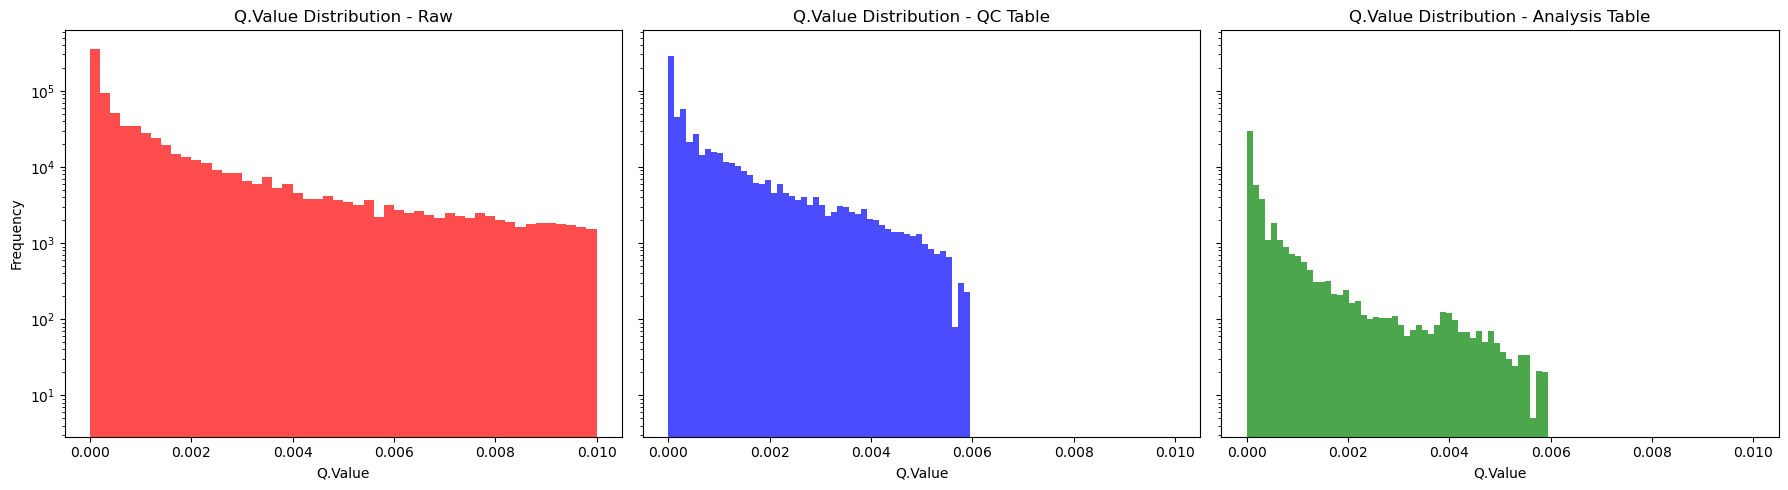

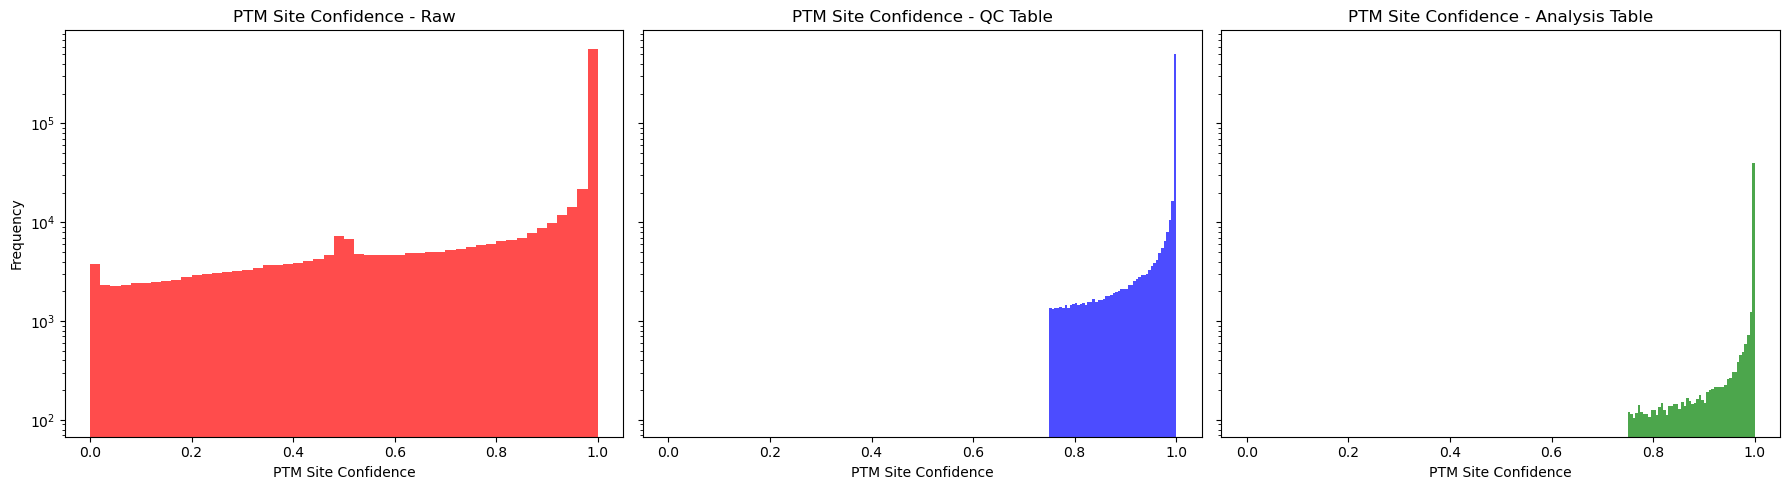

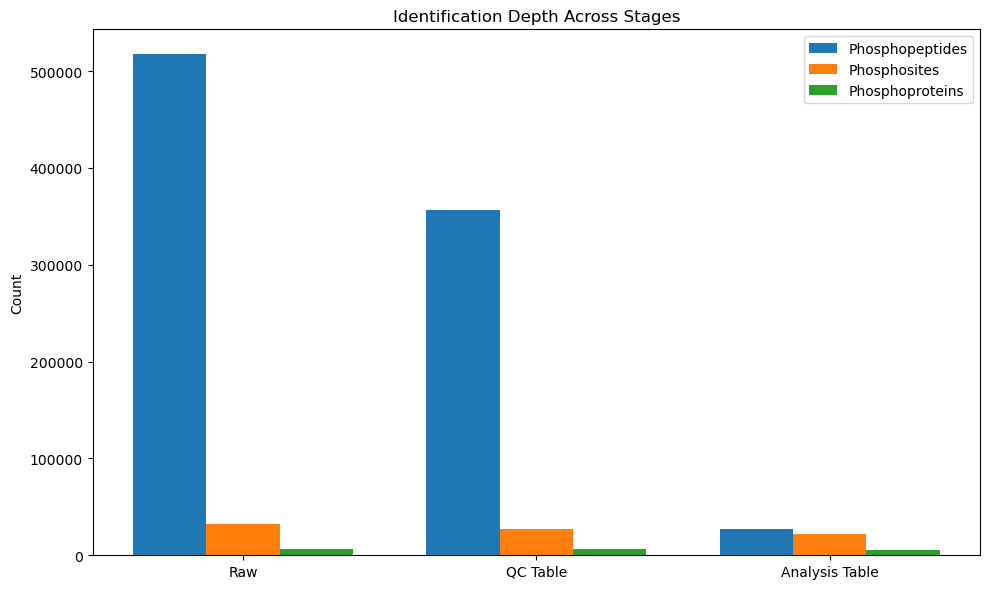

Missing value rate in raw data: 0.00%, QC table: 0.00%, Analysis table: 0.00%


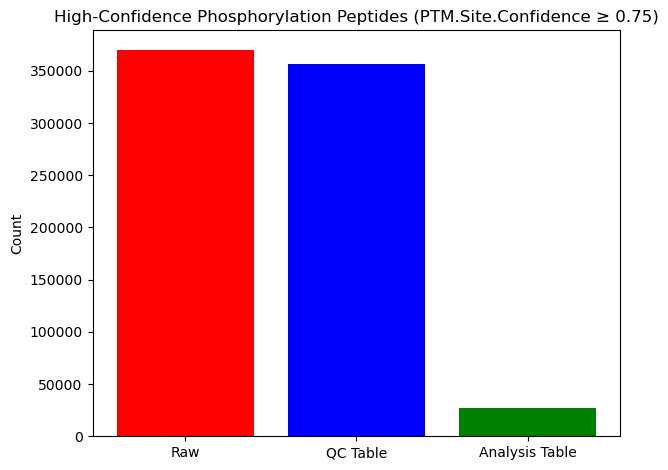

In [12]:
# Addressing Question 2: What preprocessing steps are required before beginning the main analysis?
# The preprocessing steps implemented include: data import, column removal, quality filtering (Q.Value, PEP, PTM.Site.Confidence), deduplication, data type conversion, outlier handling, phosphopeptide filtering, phosphosite extraction, normalization (per-run median), missing value imputation (KNN), and aggregation to phosphosite level.
# Why: Ensures high-confidence, normalized data for accurate phosphoproteomics analysis, addressing technical variations and biases.

# Step 7: Final check and save cleaned data
# Purpose: Save cleaned data and generate QC plots to visualize the effect of preprocessing

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Apply PTM.Site.Confidence filter (>=0.75) to QC table
# -----------------------------
qc_table = qc_table[qc_table['PTM.Site.Confidence'] >= 0.75]
analysis_table = analysis_table[analysis_table['PTM.Site.Confidence'] >= 0.75]

# -----------------------------
# 2. Check final shape and summary statistics
# -----------------------------
print(f"Final QC table shape: {qc_table.shape}")
print(f"Final analysis table shape: {analysis_table.shape}")
print(analysis_table.describe())

# -----------------------------
# 3. Save cleaned tables
# -----------------------------
#qc_table.to_excel("C:\\Users\\chuab\\Downloads\\diann_jurkats_qc_table.xlsx", index=False)
print("QC table saved to diann_jurkats_qc_table.xlsx")

#analysis_table.to_excel("C:\\Users\\chuab\\Downloads\\diann_jurkats_analysis_table.xlsx", index=False)
print("Analysis table saved to diann_jurkats_analysis_table.xlsx")

# -----------------------------
# 4. QC Plots: Before vs After Preprocessing
# -----------------------------

# 4a. Q.Value distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
axes[0].hist(data_raw['Q.Value'].dropna(), bins=50, alpha=0.7, color='red')
axes[0].set_title('Q.Value Distribution - Raw')
axes[0].set_yscale('log')
axes[0].set_xlabel('Q.Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(qc_table['Q.Value'].dropna(), bins=50, alpha=0.7, color='blue')
axes[1].set_title('Q.Value Distribution - QC Table')
axes[1].set_xlabel('Q.Value')

axes[2].hist(analysis_table['Q.Value'].dropna(), bins=50, alpha=0.7, color='green')
axes[2].set_title('Q.Value Distribution - Analysis Table')
axes[2].set_xlabel('Q.Value')

plt.tight_layout()
plt.savefig("C:\\Users\\chuab\\Downloads\\qvalue_distributions.png", dpi=300)
plt.show()

# 4b. PTM.Site.Confidence distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
axes[0].hist(data_raw['PTM.Site.Confidence'].dropna(), bins=50, alpha=0.7, color='red')
axes[0].set_title('PTM Site Confidence - Raw')
axes[0].set_xlabel('PTM Site Confidence')
axes[0].set_yscale('log')
axes[0].set_ylabel('Frequency')

axes[1].hist(qc_table['PTM.Site.Confidence'].dropna(), bins=50, alpha=0.7, color='blue')
axes[1].set_title('PTM Site Confidence - QC Table')
axes[1].set_xlabel('PTM Site Confidence')

axes[2].hist(analysis_table['PTM.Site.Confidence'].dropna(), bins=50, alpha=0.7, color='green')
axes[2].set_title('PTM Site Confidence - Analysis Table')
axes[2].set_xlabel('PTM Site Confidence')

plt.tight_layout()
plt.savefig("C:\\Users\\chuab\\Downloads\\ptm_confidence_distributions.png", dpi=300)
plt.show()

# 4c. Identification Depth (Phosphopeptides, Phosphosites, Phosphoproteins)
# Addressing Question 1: How successful was the phosphoproteomics experiment overall?
# This plot shows the number of phosphopeptides, phosphosites, and phosphoproteins identified across stages.
# Why: Quantifies the depth of phosphoproteomics coverage, indicating data richness and success compared to state-of-the-art studies.

raw_phospho = data_raw[data_raw['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
qc_phospho = qc_table[qc_table['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
analysis_phospho = analysis_table[analysis_table['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]

raw_sites = raw_phospho['Protein.Sites'].str.split(';').explode().dropna().unique() if not raw_phospho.empty else []
qc_sites = qc_phospho['Protein.Sites'].str.split(';').explode().dropna().unique() if not qc_phospho.empty else []
analysis_sites = analysis_phospho['Protein.Sites'].str.split(';').explode().dropna().unique() if not analysis_phospho.empty else []

depth_data = {
    'Phosphopeptides': [len(raw_phospho), len(qc_phospho), len(analysis_phospho)],
    'Phosphosites': [len(raw_sites), len(qc_sites), len(analysis_sites)],
    'Phosphoproteins': [
        raw_phospho['Protein.Ids'].nunique(),
        qc_phospho['Protein.Ids'].nunique(),
        analysis_phospho['Protein.Ids'].nunique()
    ]
}
stages = ['Raw', 'QC Table', 'Analysis Table']
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(stages))
for i, key in enumerate(depth_data.keys()):
    ax.bar([xi + i*0.25 for xi in x], depth_data[key], width=0.25, label=key)
ax.set_xticks([xi + 0.25 for xi in x])
ax.set_xticklabels(stages)
ax.set_title('Identification Depth Across Stages')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\chuab\\Downloads\\identification_depth.png", dpi=300)
plt.show()

# 4d. Missing value rates per run
# Addressing Question 3: What is the overall quality of the dataset?
# This plot shows missing value rates per run, assessing data completeness.
# Why: High missing values indicate poor quality; low rates suggest reliable quantification.

# do this in a single value that is printed out
# format: Missing value rate in raw data: XX.XX%, QC table: XX.XX%, Analysis table: XX.XX%
def missing_value_rate(df):
    total_values = df['Precursor.Quantity'].shape[0]
    missing_values = df['Precursor.Quantity'].isnull().sum()
    return (missing_values / total_values) * 100

missing_rates = [
    missing_value_rate(data_raw),
    missing_value_rate(qc_table),
    missing_value_rate(analysis_table)
]
print(f"Missing value rate in raw data: {missing_rates[0]:.2f}%, QC table: {missing_rates[1]:.2f}%, Analysis table: {missing_rates[2]:.2f}%")

# 4e. High-confidence phosphorylation counts (based only on PTM.Site.Confidence >= 0.75)
def count_high_conf_phospho(df):
    phospho = df[df['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
    high_conf = phospho[phospho['PTM.Site.Confidence'] >= 0.75]
    return len(high_conf)

high_conf_counts = [
    count_high_conf_phospho(data_raw),
    count_high_conf_phospho(qc_table),
    count_high_conf_phospho(analysis_table)
]

fig, ax = plt.subplots()
ax.bar(['Raw', 'QC Table', 'Analysis Table'], high_conf_counts, color=['red', 'blue', 'green'])
ax.set_title('High-Confidence Phosphorylation Peptides (PTM.Site.Confidence ≥ 0.75)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig("C:\\Users\\chuab\\Downloads\\high_conf_phospho_peptides.png", dpi=300)
plt.show()


In [13]:
# Diagnostic counts to quantify filtering impact
print("Raw rows:", len(data_raw))

qpep_pass = data_raw[(data_raw['Q.Value'] < 0.01) & (data_raw['PEP'] < 0.05)]
print("After Q.Value & PEP filter:", len(qpep_pass))

ids_pass = qpep_pass.dropna(subset=['Protein.Ids','Genes'])
print("After dropping missing Protein.Ids/Genes:", len(ids_pass))

dedup = ids_pass.sort_values('Q.Value').drop_duplicates(subset=['Modified.Sequence','Protein.Ids'], keep='first')
print("After duplicate removal:", len(dedup))

rt_filtered = dedup[(dedup['RT'] >= 0) & (dedup['RT'] <= 120)]
print("After RT & negative-value handling:", len(rt_filtered))

print("Final cleaned rows (analysis_table):", len(analysis_table))

Raw rows: 826258
After Q.Value & PEP filter: 772517
After dropping missing Protein.Ids/Genes: 772361
After duplicate removal: 61438
After RT & negative-value handling: 61438
Final cleaned rows (analysis_table): 50367


# Phosphoproteomics Data Processing Steps

This section outlines the necessary preprocessing and analysis steps to answer the provided questions about the phosphoproteomics experiment. Each step includes detailed comments explaining the purpose and rationale for the chosen method.

In [14]:
# load our data again
data_cleaned = pd.read_excel("C:\\Users\\chuab\\Downloads\\diann_jurkats_output_cleaned.xlsx")

# Step 8: Filter for phosphopeptides
# Purpose: Since this is a phosphoproteomics experiment, we need to focus only on phosphorylated peptides to answer questions about phosphosites and phosphorylation events.
# Why this method: DIA-NN marks phosphorylated residues in the 'Modified.Sequence' column with 'UniMod:21'. Filtering for rows containing 'UniMod:21' ensures we isolate phosphopeptides.
# Alternative: Parsing the sequence for specific PTM annotations, but string contains is efficient and accurate for DIA-NN output.
phospho_data = data_cleaned[data_cleaned['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
print(f"Number of phosphopeptides identified: {phospho_data.shape[0]}")
print(f"Total peptides (including non-phospho): {data_cleaned.shape[0]}")

Number of phosphopeptides identified: 37876
Total peptides (including non-phospho): 61438


In [15]:
print(data_cleaned.columns.tolist())

['Run.Index', 'Run', 'Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Lib.Index', 'Proteotypic', 'Precursor.Mz', 'Protein.Ids', 'Protein.Group', 'Protein.Names', 'Genes', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Precursor.Quantity', 'Precursor.Normalised', 'Ms1.Area', 'Ms1.Normalised', 'Ms1.Apex.Area', 'Ms1.Apex.Mz.Delta', 'Normalisation.Factor', 'Quantity.Quality', 'Empirical.Quality', 'Normalisation.Noise', 'Ms1.Profile.Corr', 'Evidence', 'Mass.Evidence', 'Channel.Evidence', 'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After', 'RT.Start', 'RT.Stop', 'FWHM', 'PG.MaxLFQ', 'Genes.MaxLFQ', 'Genes.MaxLFQ.Unique', 'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality', 'Genes.MaxLFQ.Unique.Quality', 'Q.Value', 'PEP', 'Global.Q.Value', 'Lib.Q.Value', 'Peptidoform.Q.Value', 'Global.Peptidoform.Q.Value', 'Lib.Peptidoform.Q.Value', 'PTM.Site.Confidence', 'Site.Occupancy.Probabilities', 'Protein.Sites', 'Lib.PTM.Site.Confidence', 'Channel.Q.Value', 'PG.Q.Value

In [16]:
# Check for phosphorylation markers
print(data_cleaned['Modified.Sequence'].head(10))
print("Contains UniMod:21:", data_cleaned['Modified.Sequence'].str.contains(r'UniMod:21', na=False).sum())

0                                 LKDDEVAQLK
1              DAPVHGS(UniMod:21)PTGPGAWTASK
2                                 GEEILSGAQR
3    SQALGNQNSENEILLEGDDDTLS(UniMod:21)SVDEK
4                             AGVNTVTTLVENKK
5                              ILTFDQLALDSPK
6               GEEGS(UniMod:21)DDDETENGPKPK
7                             GEEGHDPKEPEQLR
8                              SQALIEELLLYKR
9          NNS(UniMod:21)GEEFDC(UniMod:4)AFR
Name: Modified.Sequence, dtype: object
Contains UniMod:21: 37876


In [17]:
# Step 9: Extract and annotate phosphosites
# Purpose: To identify unique phosphosites for counting and analysis, as questions focus on sites, not just peptides.
# Why this method: 'Protein.Sites' column provides site positions (e.g., 'S123;T456'). We split and expand to get individual sites per row.
# Alternative: Parsing 'Modified.Sequence' for positions, but 'Protein.Sites' is pre-computed by DIA-NN and more reliable.
phospho_data['Sites_List'] = phospho_data['Protein.Sites'].str.split(';')
phospho_sites = phospho_data.explode('Sites_List').dropna(subset=['Sites_List'])
phospho_sites['Phosphosite'] = phospho_sites['Protein.Ids'] + '_' + phospho_sites['Sites_List']
print(f"Number of unique phosphosites: {phospho_sites['Phosphosite'].nunique()}")
print(f"Number of unique phosphoproteins: {phospho_sites['Protein.Ids'].nunique()}")

Number of unique phosphosites: 31610
Number of unique phosphoproteins: 6344


C:\Users\chuab\AppData\Local\Temp\ipykernel_22796\2206275227.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phospho_data['Sites_List'] = phospho_data['Protein.Sites'].str.split(';')


In [18]:
# Step 10: Normalization
# Purpose: To correct for technical variations across runs/samples, ensuring fair comparison of abundances.
# Why median normalization per run: It centers the distribution of log-transformed intensities per run to the median, robust to outliers. This corrects for run-specific biases.
# Alternative: Global median, but per-run is better for multi-run experiments.
import numpy as np
phospho_data['Precursor.Normalised_log'] = np.log2(phospho_data['Precursor.Normalised'] + 1)
phospho_data['Precursor.Normalised_norm'] = phospho_data.groupby('Run')['Precursor.Normalised_log'].transform(lambda x: x - x.median())
# Add to phospho_sites
phospho_sites['Precursor.Normalised_norm'] = phospho_data['Precursor.Normalised_norm']
print("Normalization applied to Precursor.Normalised per run.")

Normalization applied to Precursor.Normalised per run.


C:\Users\chuab\AppData\Local\Temp\ipykernel_22796\2343780630.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phospho_data['Precursor.Normalised_log'] = np.log2(phospho_data['Precursor.Normalised'] + 1)
C:\Users\chuab\AppData\Local\Temp\ipykernel_22796\2343780630.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phospho_data['Precursor.Normalised_norm'] = phospho_data.groupby('Run')['Precursor.Normalised_log'].transform(lambda x: x - x.median())


In [19]:
print(phospho_sites.columns.tolist())


['Run.Index', 'Run', 'Precursor.Id', 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Lib.Index', 'Proteotypic', 'Precursor.Mz', 'Protein.Ids', 'Protein.Group', 'Protein.Names', 'Genes', 'RT', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Precursor.Quantity', 'Precursor.Normalised', 'Ms1.Area', 'Ms1.Normalised', 'Ms1.Apex.Area', 'Ms1.Apex.Mz.Delta', 'Normalisation.Factor', 'Quantity.Quality', 'Empirical.Quality', 'Normalisation.Noise', 'Ms1.Profile.Corr', 'Evidence', 'Mass.Evidence', 'Channel.Evidence', 'Ms1.Total.Signal.Before', 'Ms1.Total.Signal.After', 'RT.Start', 'RT.Stop', 'FWHM', 'PG.MaxLFQ', 'Genes.MaxLFQ', 'Genes.MaxLFQ.Unique', 'PG.MaxLFQ.Quality', 'Genes.MaxLFQ.Quality', 'Genes.MaxLFQ.Unique.Quality', 'Q.Value', 'PEP', 'Global.Q.Value', 'Lib.Q.Value', 'Peptidoform.Q.Value', 'Global.Peptidoform.Q.Value', 'Lib.Peptidoform.Q.Value', 'PTM.Site.Confidence', 'Site.Occupancy.Probabilities', 'Protein.Sites', 'Lib.PTM.Site.Confidence', 'Channel.Q.Value', 'PG.Q.Value

In [20]:
# Step 11: Handle missing values
# Purpose: Missing values in quantitative data can bias analyses; imputation fills gaps for statistical tests.
# Why KNN imputation: It uses similar samples/peptides to estimate missing values, better than simple mean imputation which ignores patterns.
# Alternative: Min value imputation (e.g., 1% of min observed) is simpler but less accurate; KNN is preferred for proteomics.
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
phospho_data[['Precursor.Normalised_norm']] = imputer.fit_transform(phospho_data[['Precursor.Normalised_norm']])
print("Missing values imputed using KNN.")

Missing values imputed using KNN.


C:\Users\chuab\AppData\Local\Temp\ipykernel_22796\3465918923.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phospho_data[['Precursor.Normalised_norm']] = imputer.fit_transform(phospho_data[['Precursor.Normalised_norm']])


In [21]:
# Step 12: Aggregate to phosphosite level
# Purpose: Multiple peptides can map to the same site; aggregating ensures one value per site per sample for downstream analysis.
# Why median aggregation: Robust to outliers in peptide-level measurements; mean could be skewed.
# Alternative: Sum if assuming additive, but median is safer for phosphosites.
site_agg = phospho_sites.groupby(['Phosphosite', 'Run', 'group']).agg({'Precursor.Normalised_norm': 'median'}).reset_index()
print(f"Aggregated to {site_agg['Phosphosite'].nunique()} unique phosphosites across runs.")

# Optional clean-up
site_agg["group"] = site_agg["group"].astype(str).str.strip()

print("Groups kept from phospho_sites:", site_agg["group"].unique())

Aggregated to 31610 unique phosphosites across runs.
Groups kept from phospho_sites: ['stim' 'KI1-GSK' 'KI2-Stauro' 'ctrl']


In [22]:
# Check available phosphosites in your data
print("All unique phosphosites in site_agg:")
print(site_agg['Phosphosite'].unique()[:20])  # Show first 20 for brevity; remove [:20] to see all

import re

# ---- 1) Canonical sites you want to look for (human UniProt IDs) ----
# CD3/CD28 (TCR signaling examples)
# ZAP70 pY319 [web:56]
# LCK pY394 [web:62]
# LAT pY191 [web:63]
#
# GSK inhibitor readout (Wnt/β-catenin axis): CTNNB1 S33/S37/T41 (+ priming S45) [web:69][web:72]
# Staurosporine / PKC readout: MARCKS S152/S156 (classic PKC sites) [web:74]
canonical_sites = [
    # --- CD3/CD28 ---
    "P43403_Y319",  # ZAP70 [web:56]
    "P06239_Y394",  # LCK [web:62]
    "O43561_Y191",  # LAT [web:63]

    # --- GSK inhibitor (GSK3) ---
    "P35222_S33",   # CTNNB1 (β-catenin) [web:69][web:72]
    "P35222_S37",   # CTNNB1 [web:69][web:72]
    "P35222_T41",   # CTNNB1 [web:69][web:72]
    "P35222_S45",   # CTNNB1 priming site [web:69][web:72]

    # --- Staurosporine (broad kinase inhibitor; PKC substrate example) ---
    "P29966_S152",  # MARCKS [web:74]
    "P29966_S156",  # MARCKS [web:74]
]

# ---- 2) Helper: find exact residue+position within your Phosphosite string ----
# Your Phosphosite values look like: "P06239_[P06239:S121]" etc. [file:2]
def match_dataset_phosphosite(site_series, canonical):
    protein, rp = canonical.split("_")     # e.g. P06239, Y394
    residue = rp[0]                        # Y
    pos = rp[1:]                           # 394

    # Match "protein_[protein:...Y394...]" anywhere inside the bracket part
    # Works also if multiple sites appear like "...:T93,S95,S99" [file:2]
    pattern = rf"^{re.escape(protein)}_.*\[{re.escape(protein)}:.*\b{re.escape(residue)}{re.escape(pos)}\b.*\]"
    hits = site_series[site_series.str.contains(pattern, regex=True, na=False)]
    return hits.unique().tolist()

# ---- 3) Run matching ----
site_series = site_agg["Phosphosite"].astype(str)

canonical_to_dataset = {}   # canonical -> list of matching dataset IDs
for cs in canonical_sites:
    canonical_to_dataset[cs] = match_dataset_phosphosite(site_series, cs)

found = {k: v for k, v in canonical_to_dataset.items() if len(v) > 0}
missing = [k for k, v in canonical_to_dataset.items() if len(v) == 0]

print("Found canonical sites (mapped to your dataset IDs):")
for k, v in found.items():
    print(f"  {k} -> {v}")

print("\nMissing canonical sites (no exact residue+position match found):")
print(missing)

# ---- 4) If missing, print suggestions: all sites present for that protein ----
if len(missing) > 0:
    print("\nSuggestions (sites detected for each missing protein):")
    for cs in missing:
        protein = cs.split("_")[0]
        suggestions = site_series[site_series.str.startswith(protein)].unique()
        print(f"  {protein}: {list(suggestions)[:15]}")  # show up to 15



All unique phosphosites in site_agg:
['A0A087WUV0_[A0A087WUV0:S55]' 'A0A087WUV0_[A0A087WUV0:T112]'
 'A0A0A6YYC5_[A0A0A6YYC5:S62]'
 'A0A0B4J2A2;P0DN37_[A0A0B4J2A2:T93,S95,S99,C115]'
 'A0A1W2PQ72_[A0A1W2PQ72:T243]' 'A0A286YF18_[A0A286YF18:S30]'
 'A0A2R8Y4L2;P09651_[P09651:S199]' 'A0A2R8Y4L2;P09651_[P09651:S368]'
 'A0A2R8Y4L2;Q32P51;P09651_[P09651:S142]'
 'A0A2R8Y4L2;Q32P51;P09651_[P09651:S158]'
 'A0A2Z4LIS9;P0CG31_[A0A2Z4LIS9:S16]' 'A0A2Z4LIS9;P0CG31_[A0A2Z4LIS9:S19]'
 'A0A2Z4LIS9_[A0A2Z4LIS9:S160]' 'A0A2Z4LIS9_[A0A2Z4LIS9:S170]'
 'A0A3B3IU46;Q9BTL3_[Q9BTL3:S36]' 'A0A494C030_[A0A494C030:T152]'
 'A0A590UJ96_[A0A590UJ96:S346,C359]'
 'A0A590UK10;Q6ZSZ5_[Q6ZSZ5:C918,S921]'
 'A0A590UK10;Q6ZSZ5_[Q6ZSZ5:C918,T923]'
 'A0A590UK10;Q6ZSZ5_[Q6ZSZ5:S1289,S1291]']
Found canonical sites (mapped to your dataset IDs):
  P43403_Y319 -> ['P43403_[P43403:Y319]']

Missing canonical sites (no exact residue+position match found):
['P06239_Y394', 'O43561_Y191', 'P35222_S33', 'P35222_S37', 'P35222_T41', 'P35222_

In [23]:
# Addressing Question 5: Do known phosphosites behave as expected?
# Check canonical TCR signaling sites (e.g., ZAP70_Y319, LCK_Y394) for expected upregulation in stim and reduction in inhibitors.
# Why: Validates the experiment by confirming known biology matches observed changes.

import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# 0) Pick intensity column
# ----------------------------
# In your notebook it is Precursor.Normalisednorm (no underscore) [file:23]
candidate_ycols = [
    "Precursor_Normalised_norm"
]
ycol = next((c for c in candidate_ycols if c in site_agg.columns), None)
if ycol is None:
    raise ValueError(f"No intensity column found. Available columns: {list(site_agg.columns)}")

# ----------------------------
# 1) Canonical site candidates
#    (We will only plot those that exist in YOUR dataset)
# ----------------------------
canonical_sites = [
    # --- TCR / CD3-CD28 ---
    "P43403_Y319",  # ZAP70 (you already found this one)
    "P06239_Y394",  # LCK (often missing in MS)
    "P06239_Y505",  # LCK (you DO have Y505 in your suggestions)
    "O43561_Y191",  # LAT (often missing)
    "O43561_Y220",  # LAT (you DO have Y220 in your suggestions)

    # --- GSK inhibitor readout (CTNNB1) ---
    "P35222_S33",
    "P35222_S37",
    "P35222_T41",
    "P35222_S45",
    "P35222_S552",  # you DO have S552 in your suggestions
    "P35222_S675",  # you DO have S675 in your suggestions
    "P35222_T551",  # you DO have T551 in your suggestions

    # --- Staurosporine / PKC readout (MARCKS) ---
    "P29966_S152",
    "P29966_S156",
    "P29966_S170",  # you DO have S170 in your suggestions
]

# ----------------------------
# 2) Map canonical -> dataset phosphosite IDs
# ----------------------------
def map_canonical_to_dataset(site_series, canonical):
    protein, rp = canonical.split("_")  # e.g. P43403, Y319
    residue = rp[0]
    pos = rp[1:]

    # Match the bracket part anywhere, e.g. "..._[P43403:Y319]" or "...;P06239;..._[P06239:Y394]"
    pattern = rf"\[{re.escape(protein)}:.*\b{re.escape(residue)}{re.escape(pos)}\b.*\]"
    hits = site_series[site_series.str.contains(pattern, regex=True, na=False)]
    return hits.unique().tolist()

site_series = site_agg["Phosphosite"].astype(str)
canonical_to_dataset = {cs: map_canonical_to_dataset(site_series, cs) for cs in canonical_sites}

found = {cs: ds for cs, ds in canonical_to_dataset.items() if len(ds) > 0}
missing = [cs for cs, ds in canonical_to_dataset.items() if len(ds) == 0]

print("Found canonical sites (mapped to your dataset IDs):")
for cs, ds in found.items():
    print(f"  {cs} -> {ds}")

print("\nMissing canonical sites (not detected in your dataset):")
print(missing)

# Flatten to dataset IDs we will plot
available_sites = sorted({x for ds in found.values() for x in ds})
print("\nWill plot these dataset sites:")
print(available_sites)

# ----------------------------
# 3) Plot (better than a boxplot for 1–2 sites)
#    Each dot = one Run, with a median line.
# ----------------------------
if len(available_sites) == 0:
    print("No canonical sites were found in your dataset.")
else:
    plot_data = site_agg[site_agg["Phosphosite"].isin(available_sites)].copy()

    # Optional: enforce a consistent group order if present
    group_order = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]
    group_order = [g for g in group_order if g in plot_data["group"].unique()]

    g = sns.catplot(
        data=plot_data,
        x="group", y=ycol,
        col="Phosphosite",
        col_wrap=2,
        order=group_order if len(group_order) > 0 else None,
        kind="strip",      # dots per Run
        jitter=0.15,
        alpha=0.8,
        height=4
    )
    g.set_axis_labels("Group", "Normalized intensity")
    g.set_titles("{col_name}")

    # Add median line per group inside each facet
    for ax in g.axes.flatten():
        title = ax.get_title().replace("Phosphosite = ", "")
        tmp = plot_data[plot_data["Phosphosite"] == title]
        med = tmp.groupby("group")[ycol].median()
        xs = group_order if len(group_order) > 0 else list(med.index)
        ax.plot(xs, [med.get(x, float("nan")) for x in xs], color="black", linewidth=1)
    plt.tight_layout()
    plt.show()




ValueError: No intensity column found. Available columns: ['Phosphosite', 'Run', 'group', 'Precursor.Normalised_norm']

In [ ]:
print(site_agg.columns.tolist())

['Phosphosite', 'Run', 'group', 'Precursor.Normalised_norm']


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# -----------------------------
# Settings
# -----------------------------
GROUPORDER = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]
MIN_RUNS_PER_GROUP = 2   # >=2 run-values per group for ANOVA

# -----------------------------
# 0) Unify the intensity column name
# -----------------------------
# IMPORTANT: in your notebook the column is "Precursor.Normalisednorm" (no underscore). [file:15]
target_col = "Precursor.Normalised_norm"

site_agg = site_agg.copy()
site_agg["group"] = site_agg["group"].astype(str).str.strip()

if target_col in site_agg.columns:
    site_agg = site_agg.rename(columns={target_col: "Intensity"})
    print(f"Successfully renamed '{target_col}' to 'Intensity'")
elif "Intensity" in site_agg.columns:
    print("Column 'Intensity' already exists. Proceeding...")
else:
    raise ValueError(
        f"Column '{target_col}' not found. Available columns: {list(site_agg.columns)}"
    )

intensity_col = "Intensity"

# keep only expected groups (prevents typos creating extra groups)
site_agg = site_agg[site_agg["group"].isin(GROUPORDER)].copy()

# -----------------------------
# 1) ANOVA per phosphosite (with replicate filter)
# -----------------------------
print("Unique groups identified:", site_agg["group"].unique())

p_values = []

for site, site_data in site_agg.groupby("Phosphosite"):
    clean_data = site_data.dropna(subset=[intensity_col])

    group_lists = clean_data.groupby("group")[intensity_col].apply(list).to_dict()

    # Rule A: require ALL 4 groups present
    if not all(g in group_lists for g in GROUPORDER):
        p_values.append((site, np.nan))
        continue

    # Rule B: require enough run values per group
    if any(len(group_lists[g]) < MIN_RUNS_PER_GROUP for g in GROUPORDER):
        p_values.append((site, np.nan))
        continue

    stat, p = stats.f_oneway(*[group_lists[g] for g in GROUPORDER])
    p_values.append((site, p))

p_values_df = pd.DataFrame(p_values, columns=["Phosphosite", "p_value"])
print(
    f"ANOVA completed (non-NaN p-values) for {p_values_df['p_value'].notna().sum()} phosphosites "
    f"out of {len(p_values_df)} total."
)

# -----------------------------
# 1b) Coverage / replicate check per phosphosite (NEW)
# -----------------------------
coverage_long = (
    site_agg
    .dropna(subset=[intensity_col])
    .groupby(["Phosphosite", "group"])["Run"]
    .nunique()                      # number of runs with a value
    .reset_index(name="n_runs")
)

coverage_wide = (
    coverage_long
    .pivot(index="Phosphosite", columns="group", values="n_runs")
    .reindex(columns=GROUPORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)

coverage_wide["passes_anova_minruns"] = (coverage_wide[GROUPORDER] >= MIN_RUNS_PER_GROUP).all(axis=1)

print("Total phosphosites in coverage table:", len(coverage_wide))
print(f"Phosphosites passing >= {MIN_RUNS_PER_GROUP} runs in EACH group:",
      coverage_wide["passes_anova_minruns"].sum())

# Which sites fail (these typically match ANOVA NaNs due to coverage)
fails = coverage_wide[~coverage_wide["passes_anova_minruns"]].copy()
print("Phosphosites failing replicate rule:", len(fails))

# show some examples (lowest coverage first)
print(fails.sort_values(GROUPORDER).head(20))

# save tables so you can open in Excel
coverage_wide.to_csv("phosphosite_replicate_coverage.csv", index=False)
fails.to_csv("phosphosite_replicate_fails.csv", index=False)

# -----------------------------
# 2) Pairwise Welch t-tests per phosphosite
# -----------------------------
comparisons = [
    ("stim", "ctrl"),
    ("KI1-GSK", "stim"),
    ("KI2-Stauro", "stim"),
    ("KI2-Stauro", "KI1-GSK"),
]

results = []

for site, df_site in site_agg.groupby("Phosphosite"):
    for g1, g2 in comparisons:
        x = df_site.loc[df_site["group"] == g1, intensity_col].dropna()
        y = df_site.loc[df_site["group"] == g2, intensity_col].dropna()

        if (len(x) >= 2) and (len(y) >= 2):
            stat, p = ttest_ind(x, y, equal_var=False)
        else:
            p = np.nan

        results.append([site, f"{g1}_vs_{g2}", p])

pairwise_pvals = pd.DataFrame(results, columns=["Phosphosite", "comparison", "p_value"])
print("Pairwise comparisons complete.")


Successfully renamed 'Precursor.Normalised_norm' to 'Intensity'
Unique groups identified: ['stim' 'KI1-GSK' 'KI2-Stauro' 'ctrl']
ANOVA completed (non-NaN p-values) for 0 phosphosites out of 31610 total.
Total phosphosites in coverage table: 31610
Phosphosites passing >= 2 runs in EACH group: 0
Phosphosites failing replicate rule: 31610
group                                      Phosphosite  ctrl  stim  KI1-GSK  \
3      A0A0B4J2A2;P0DN37_[A0A0B4J2A2:T93,S95,S99,C115]     0     0        0   
9               A0A2R8Y4L2;Q32P51;P09651_[P09651:S158]     0     0        0   
10                  A0A2Z4LIS9;P0CG31_[A0A2Z4LIS9:S16]     0     0        0   
16                   A0A590UJ96_[A0A590UJ96:S346,C359]     0     0        0   
27                      A0A8I5KQE6;P08865_[P08865:T97]     0     0        0   
29                                A0AVK6_[A0AVK6:S225]     0     0        0   
32                                 A0AVK6_[A0AVK6:S52]     0     0        0   
38                            

Groups in phospho_sites:
group
stim          18112
KI1-GSK        8566
KI2-Stauro     6482
ctrl           4831
Name: count, dtype: int64

Example Run→group mapping (from your existing group column):
                                                     Run       group
1      Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        stim
22586  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        stim
24127  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        ctrl
25154  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...     KI1-GSK
25892  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        stim
26312  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        stim
26453  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...  KI2-Stauro
27789  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...  KI2-Stauro
28044  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...     KI1-GSK
28167  Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_s...        ctrl
28205  Stitch_241125_S4783_IB_MGR_Jurkat_S

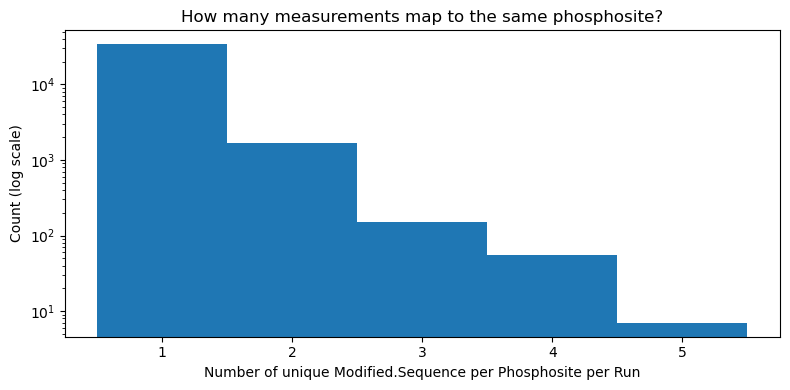


Comparisons that ran: ['stim_vs_ctrl', 'KI1_vs_stim', 'KI2_vs_stim']
No results for: stim_vs_ctrl: UP (higher in first group)
No results for: stim_vs_ctrl: DOWN (lower in first group)
No results for: KI1_vs_stim: UP (higher in first group)
No results for: KI1_vs_stim: DOWN (lower in first group)
No results for: KI2_vs_stim: UP (higher in first group)
No results for: KI2_vs_stim: DOWN (lower in first group)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from gprofiler import GProfiler


# -----------------------------
# 0) Benjamini–Hochberg FDR
# -----------------------------
def bh_fdr(pvals):
    """
    Convert many p-values into q-values (FDR-adjusted p-values).
    Needed because we test thousands of phosphosites, so some low p-values
    will occur by chance.
    """
    p = np.asarray(pvals, dtype=float)
    n = p.size

    order = np.argsort(p)
    ranked_p = p[order]

    q = ranked_p * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    out = np.empty_like(q)
    out[order] = q
    return out


GROUP_ORDER = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]


# -----------------------------
# 1) Validate input: phospho_sites
# -----------------------------
required_cols = {"Phosphosite", "Run", "group", "Precursor.Normalised_norm"}
missing = required_cols - set(phospho_sites.columns)
if missing:
    raise ValueError(f"phospho_sites missing required columns: {missing}")

phospho_sites = phospho_sites.copy()

# Keep group column (do NOT rebuild from Run)
phospho_sites["group"] = phospho_sites["group"].astype(str).str.strip()

# Keep only expected groups (prevents typos/spaces creating extra groups)
phospho_sites = phospho_sites[phospho_sites["group"].isin(GROUP_ORDER)].copy()

print("Groups in phospho_sites:")
print(phospho_sites["group"].value_counts())
print("\nExample Run→group mapping (from your existing group column):")
print(phospho_sites[["Run", "group"]].drop_duplicates().head(20))


# -----------------------------
# 2) Aggregate to phosphosite level
# -----------------------------
site_agg = (
    phospho_sites
    .groupby(["Phosphosite", "Run", "group"], as_index=False)
    .agg(Precursor_Normalised_norm=("Precursor.Normalised_norm", "median"))
)

print("\nGroups in site_agg:")
print(site_agg["group"].value_counts())


# -----------------------------
# 2B) OPTION B (ADDED): match only by protein ID (less strict)
# -----------------------------
def sites_for_protein(site_agg_df: pd.DataFrame, protein_id: str, top_n=30):
    """
    Lists Phosphosite strings that start with a given protein_id.
    Works with your dataset format like: P06239P06239S121..., etc.
    """
    protein_id = str(protein_id).strip()

    hits = (
        site_agg_df.loc[
            site_agg_df["Phosphosite"].astype(str).str.startswith(protein_id),
            "Phosphosite"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"\nProtein {protein_id}: {len(hits)} phosphosites found in dataset.")
    if len(hits) == 0:
        print("No matches. Check if your Protein.Ids / Phosphosite format differs.")
        return []

    print(f"Example sites (first {min(top_n, len(hits))}):")
    for s in hits[:top_n]:
        print(" -", s)

    return hits


def heatmap_for_protein(site_agg_df: pd.DataFrame, protein_id: str,
                        value_col="Precursor_Normalised_norm",
                        group_order=None):
    """
    Heatmap for all sites belonging to one protein.
    Rows: Phosphosite
    Columns: group (median across runs)
    """
    if group_order is None:
        group_order = GROUP_ORDER

    protein_id = str(protein_id).strip()
    protein_sites = site_agg_df[site_agg_df["Phosphosite"].astype(str).str.startswith(protein_id)].copy()

    if protein_sites.empty:
        print(f"No sites to plot for {protein_id}")
        return

    mat = (
        protein_sites.groupby(["Phosphosite", "group"])[value_col]
        .median()
        .reset_index()
        .pivot(index="Phosphosite", columns="group", values=value_col)
    )

    mat = mat.reindex(columns=[g for g in group_order if g in mat.columns])

    plt.figure(figsize=(6, max(3, 0.25 * mat.shape[0])))
    # NOTE: this is not logFC, so do NOT force center=0 unless you know the values are centered
    sns.heatmap(mat, cmap="rocket")
    plt.title(f"{protein_id}: phosphosite intensity (median per group)")
    plt.xlabel("Group")
    plt.ylabel("Phosphosite")
    plt.tight_layout()
    plt.show()


# Example usage (updated for anti-CD3/CD28 + useful inhibitor readouts)
proteins_of_interest = [
    "P20963",  # CD247 (CD3 zeta) [TCR ITAM chain]
    "P06239",  # LCK
    "P43403",  # ZAP70
    "O43561",  # LAT
    "P29966",  # MARCKS (PKC substrate; useful for stauro/PKC readout)
]

protein_to_sites = {pid: sites_for_protein(site_agg, pid) for pid in proteins_of_interest}


# -----------------------------
# 3) OPTIONAL: show multi-mapping per site
# -----------------------------
count_cols = []
if "Modified.Sequence" in phospho_sites.columns:
    count_cols.append("Modified.Sequence")
elif "Precursor.Id" in phospho_sites.columns:
    count_cols.append("Precursor.Id")

if count_cols:
    id_col = count_cols[0]
    multi_map = (
        phospho_sites
        .groupby(["Phosphosite", "Run"], as_index=False)
        .agg(n_measurements=(id_col, "nunique"))
    )

    # --- UPDATED PLOT ONLY (whole-number x ticks + log-scale y) ---
    x = multi_map["n_measurements"].dropna().astype(int).values
    xmin, xmax = int(np.min(x)), int(np.max(x))
    bins = np.arange(xmin - 0.5, xmax + 1.5, 1)

    plt.figure(figsize=(8, 4))
    plt.hist(x, bins=bins)
    plt.xticks(np.arange(xmin, xmax + 1, 1))   # whole numbers on x-axis
    plt.yscale("log")                          # log scale on y-axis
    plt.xlabel(f"Number of unique {id_col} per Phosphosite per Run")
    plt.ylabel("Count (log scale)")
    plt.title("How many measurements map to the same phosphosite?")
    plt.tight_layout()
    plt.show()
    # --- END UPDATE ---


# -----------------------------
# 4) Map Phosphosite -> Gene (prefer Genes column)
# -----------------------------
def first_item(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    for sep in [";", ",", " "]:
        if sep in s:
            return s.split(sep)[0]
    return s


if "Genes" in phospho_sites.columns:
    tmp = phospho_sites[["Phosphosite", "Genes"]].dropna().copy()
    tmp["Gene1"] = tmp["Genes"].apply(first_item)
    site_to_gene = (
        tmp.dropna()
        .drop_duplicates("Phosphosite")
        .set_index("Phosphosite")["Gene1"]
    )
else:
    # fallback (not ideal): use Protein.Ids
    tmp = phospho_sites[["Phosphosite", "Protein.Ids"]].dropna().copy()
    tmp["Gene1"] = tmp["Protein.Ids"].apply(first_item)
    site_to_gene = (
        tmp.dropna()
        .drop_duplicates("Phosphosite")
        .set_index("Phosphosite")["Gene1"]
    )


# -----------------------------
# 5) Build site × run matrix
# -----------------------------
site_run = site_agg.pivot_table(
    index="Phosphosite",
    columns="Run",
    values="Precursor_Normalised_norm",
    aggfunc="median"
)

run_group = site_agg[["Run", "group"]].drop_duplicates().set_index("Run")["group"]


# -----------------------------
# 6) Pairwise stats per phosphosite
#    Welch t-test -> p-values -> BH-FDR -> q-values
# -----------------------------
def pairwise_site_stats(site_run_wide: pd.DataFrame,
                        run_to_group: pd.Series,
                        group_a: str,
                        group_b: str):

    runs_a = run_to_group[run_to_group == group_a].index.intersection(site_run_wide.columns)
    runs_b = run_to_group[run_to_group == group_b].index.intersection(site_run_wide.columns)

    if len(runs_a) < 2 or len(runs_b) < 2:
        print(f"Skipping {group_a} vs {group_b}: need >=2 runs per group (got {len(runs_a)} and {len(runs_b)})")
        return None

    med_a = site_run_wide[runs_a].median(axis=1, skipna=True)
    med_b = site_run_wide[runs_b].median(axis=1, skipna=True)
    log2fc = med_a - med_b

    pvals = []
    for site in site_run_wide.index:
        a = site_run_wide.loc[site, runs_a].dropna().values
        b = site_run_wide.loc[site, runs_b].dropna().values
        if len(a) < 2 or len(b) < 2:
            pvals.append(np.nan)
        else:
            # Welch t-test
            pvals.append(ttest_ind(a, b, equal_var=False).pvalue)

    df = pd.DataFrame({
        "Phosphosite": site_run_wide.index,
        "log2FC": log2fc.values,
        "p_value": np.array(pvals)
    }).dropna(subset=["p_value"])

    df["q_value"] = bh_fdr(df["p_value"].values)
    return df


comparisons = [
    ("stim", "ctrl", "stim_vs_ctrl"),
    ("KI1-GSK", "stim", "KI1_vs_stim"),
    ("KI2-Stauro", "stim", "KI2_vs_stim"),
]

results = {}
for ga, gb, name in comparisons:
    out = pairwise_site_stats(site_run, run_group, ga, gb)
    if out is not None:
        results[name] = out

print("\nComparisons that ran:", list(results.keys()))


# -----------------------------
# 7) Build UP/DOWN gene lists
# -----------------------------
def regulated_gene_lists(res_df, fc_cutoff=0.5, q_cutoff=0.05, min_genes=10):
    df = res_df[(res_df["q_value"] < q_cutoff) & (res_df["log2FC"].abs() >= fc_cutoff)].copy()
    if df.empty:
        return [], []

    df["Gene"] = df["Phosphosite"].map(site_to_gene)
    df = df.dropna(subset=["Gene"])

    up = df[df["log2FC"] > 0]["Gene"].unique().tolist()
    down = df[df["log2FC"] < 0]["Gene"].unique().tolist()

    up = up if len(up) >= min_genes else []
    down = down if len(down) >= min_genes else []
    return up, down


# -----------------------------
# 8) g:Profiler enrichment + dotplot
# -----------------------------
gp = GProfiler(return_dataframe=True)


def gprofiler_enrich(gene_list, sources=("GO:BP", "REAC", "KEGG")):
    if gene_list is None or len(gene_list) == 0:
        return pd.DataFrame()
    return gp.profile(organism="hsapiens", query=gene_list, sources=list(sources))


def dotplot_enrichment(enrich_df, title, top_n=20, p_cutoff=0.05):
    if enrich_df is None or enrich_df.empty:
        print(f"No results for: {title}")
        return

    pcol = "p_value" if "p_value" in enrich_df.columns else None
    if pcol is None:
        print(f"Could not find p-value column in g:Profiler results for: {title}")
        return

    df = enrich_df[enrich_df[pcol] < p_cutoff].copy()
    if df.empty:
        print(f"No significant terms (p<{p_cutoff}) for: {title}")
        return

    df = df.sort_values(pcol, ascending=True).head(top_n)
    df["score"] = -np.log10(df[pcol].clip(lower=1e-300))

    plt.figure(figsize=(10, max(4, 0.35 * len(df))))
    plt.scatter(df["score"], range(len(df)), s=60)
    name_col = "name" if "name" in df.columns else ("term_name" if "term_name" in df.columns else None)
    plt.yticks(range(len(df)), df[name_col] if name_col else df.index.astype(str))
    plt.xlabel("-log10(p-value)")
    plt.title(title)
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


# -----------------------------
# 9) Run enrichment per comparison
# -----------------------------
for comp_name, res_df in results.items():
    up_genes, down_genes = regulated_gene_lists(res_df, fc_cutoff=0.5, q_cutoff=0.05, min_genes=10)

    enr_up = gprofiler_enrich(up_genes)
    dotplot_enrichment(enr_up, f"{comp_name}: UP (higher in first group)")

    enr_down = gprofiler_enrich(down_genes)
    dotplot_enrichment(enr_down, f"{comp_name}: DOWN (lower in first group)")


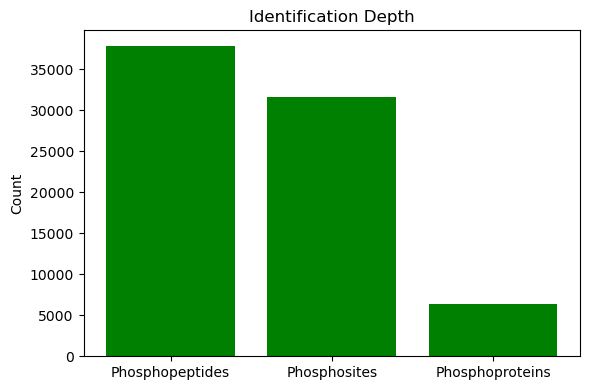

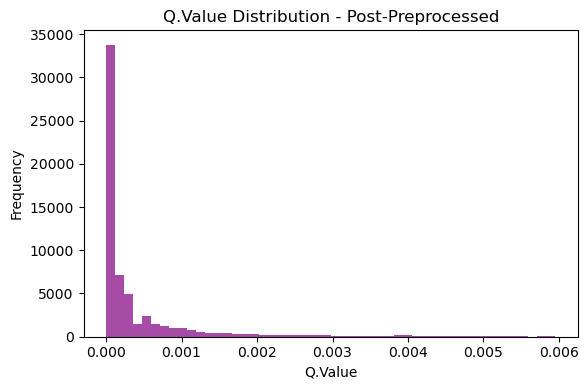

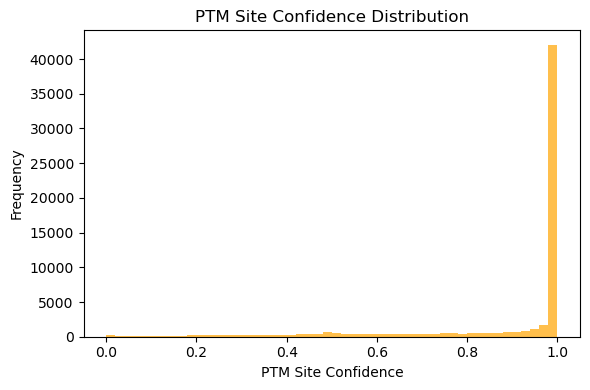

C:\Users\chuab\AppData\Local\Temp\ipykernel_5996\3075424914.py:75: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


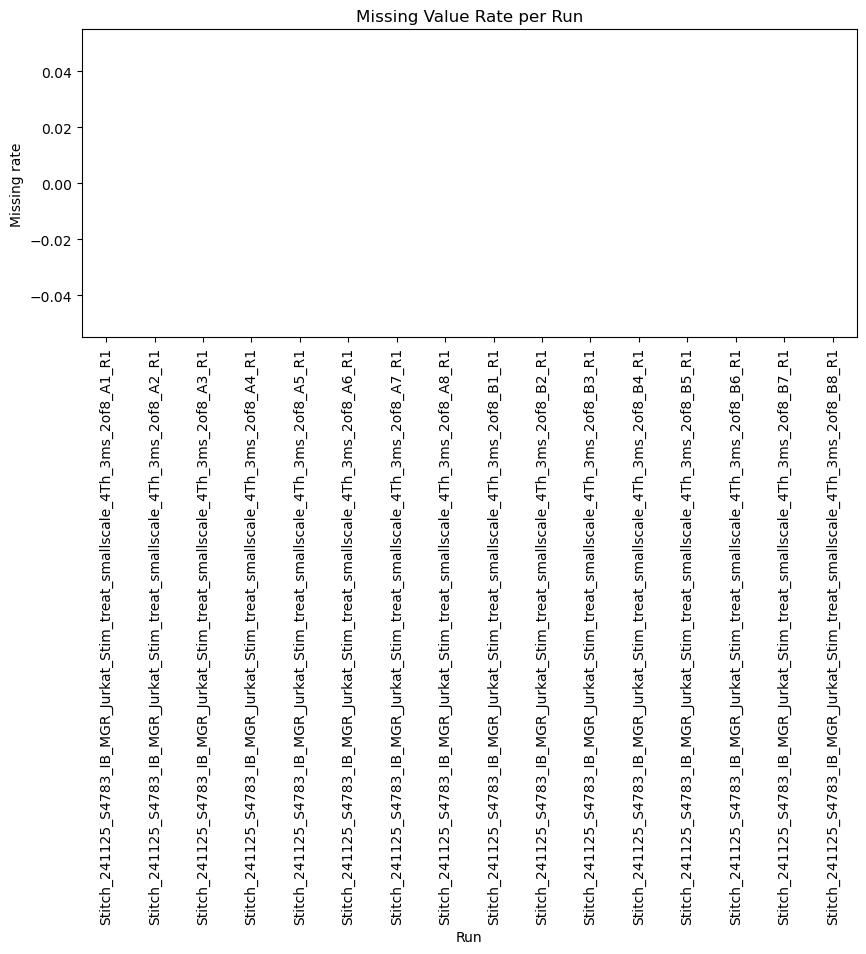

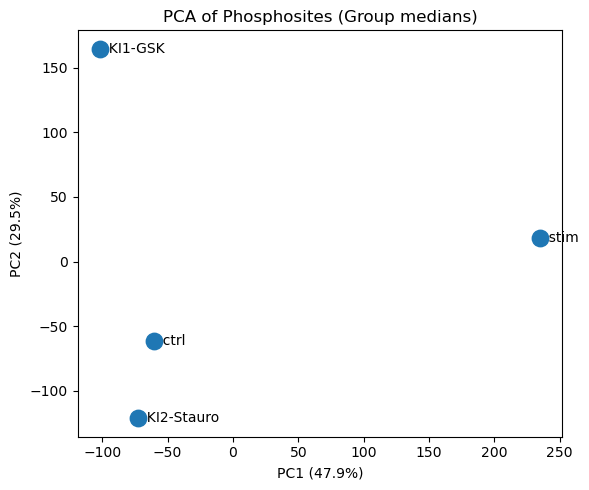

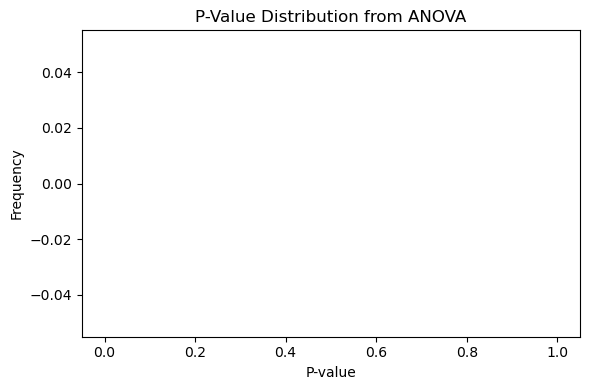

No significant sites for heatmap.
No significant sites for heatmap.


In [ ]:
# Step 15: Visualization and quality assessment (UPDATED, GROUP-BASED)
# Uses variables from your notebook:
# datacleaned, phosphodata, phosphosites, site_agg, pvaluesdf, sigsites

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# -----------------------------
# 0) Helper: consistent group order (only keeps groups that exist)
# -----------------------------
desired_group_order = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]

def keep_existing_groups(cols, desired_order):
    return [g for g in desired_order if g in list(cols)]


# ============================================================
# Phosphoproteomics QC Plots (Post-Preprocessing)
# ============================================================

# -----------------------------
# 1) Identification depth
# -----------------------------
depth = {
    "Phosphopeptides": phospho_data.shape[0],
    "Phosphosites": phospho_sites["Phosphosite"].nunique(),
    "Phosphoproteins": phospho_sites["Protein.Ids"].nunique()
}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(depth.keys(), depth.values(), color="green")
ax.set_title("Identification Depth")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Q-value distribution
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_cleaned["Q.Value"].dropna(), bins=50, alpha=0.7, color="purple")
ax.set_title("Q.Value Distribution - Post-Preprocessed")
ax.set_xlabel("Q.Value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


# -----------------------------
# 3) PTM site confidence distribution
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data_cleaned["PTM.Site.Confidence"].dropna(), bins=50, alpha=0.7, color="orange")
ax.set_title("PTM Site Confidence Distribution")
ax.set_xlabel("PTM Site Confidence")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


# -----------------------------
# 4) Missing value rate per run (QC is run-level)
# -----------------------------
missing_per_run = phospho_data.groupby("Run")["Precursor.Normalised"].apply(lambda x: x.isna().mean())

fig, ax = plt.subplots(figsize=(10, 4))
missing_per_run.plot(kind="bar", ax=ax, color="cyan")
ax.set_title("Missing Value Rate per Run")
ax.set_ylabel("Missing rate")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# -----------------------------
# 5) PCA based on GROUPS (biological)
# One point per group = group median profile across phosphosites
# -----------------------------
# Median per phosphosite per group
# Median per phosphosite per group (USE site_agg)
site_group = (
    site_agg
    .groupby(["Phosphosite", "group"])["Precursor_Normalised_norm"]
    .median()
    .reset_index()
)

site_wide = (
    site_group
    .pivot(index="Phosphosite", columns="group", values="Precursor_Normalised_norm")
    .fillna(0)
)


# Optional: order groups
site_wide = site_wide[keep_existing_groups(site_wide.columns, desired_group_order)]

# PCA on groups (transpose so rows = groups)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(site_wide.T)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pca_result[:, 0], pca_result[:, 1], s=140)

for i, g in enumerate(site_wide.columns):
    ax.text(pca_result[i, 0], pca_result[i, 1], f"  {g}", va="center")

ax.set_title("PCA of Phosphosites (Group medians)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()


# ============================================================
# Biological Result Plots
# ============================================================

# -----------------------------
# 6) P-value distribution from ANOVA
# Note: in your notebook it's pvaluesdf with column name 'pvalue'
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_values_df["p_value"].dropna(), bins=50, alpha=0.7, color="red")
ax.set_title("P-Value Distribution from ANOVA")
ax.set_xlabel("P-value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


# -----------------------------
# 7) Heatmap of significantly regulated phosphosites (GROUP-BASED)
# Uses the same site_wide (phosphosite x group) as PCA
# -----------------------------
# 1) Build sig_sites from your ANOVA results (Step 13)
alpha = 0.05
sig_sites = (
    p_values_df.loc[p_values_df["p_value"] < alpha, "Phosphosite"]
    .dropna()
    .tolist()
)

# 2) Plot heatmap (top 50)
if len(sig_sites) > 0:
    top_sites = sig_sites[:50]

    heatmap_data = site_wide.loc[site_wide.index.intersection(top_sites)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap="RdYlBu_r", center=0)
    plt.title("Heatmap of Significant Phosphosites (by group)")
    plt.xlabel("Group")
    plt.ylabel("Phosphosite")
    plt.tight_layout()
    plt.show()
else:
    print("No significant sites for heatmap.")

    print("No significant sites for heatmap.")


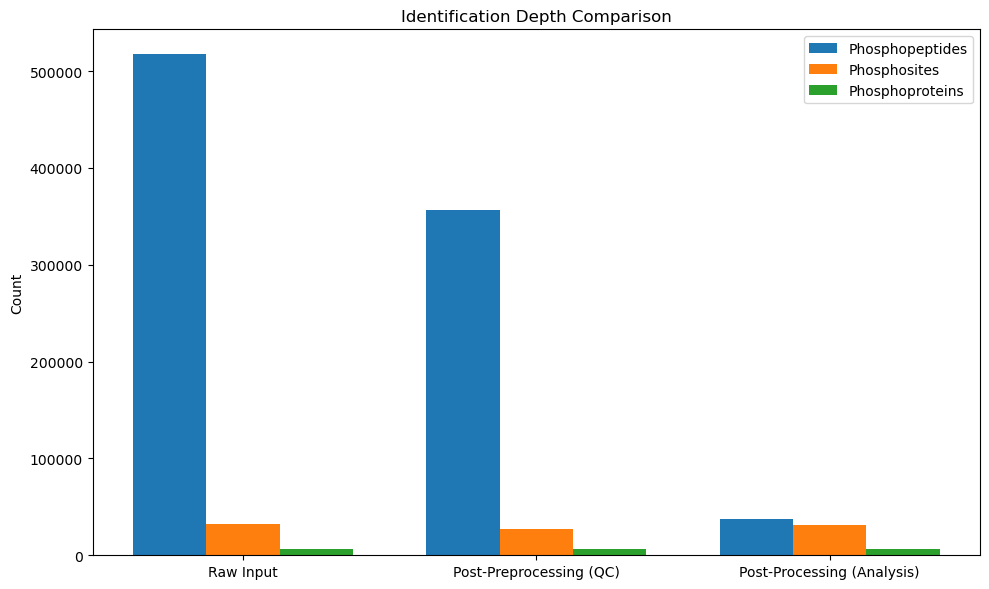

In [ ]:
# Comparison Plots: Preprocessing vs Downstream Results

# Load QC table for comparison
qc_table = pd.read_excel("C:\\Users\\chuab\\Downloads\\diann_jurkats_qc_table.xlsx")

# 1. Identification depth at three stages
raw_phospho = data_raw[data_raw['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
qc_phospho = qc_table[qc_table['Modified.Sequence'].str.contains(r'UniMod:21', na=False)]
analysis_phospho = phospho_data  # From Step 8

raw_sites = raw_phospho['Protein.Sites'].str.split(';').explode().dropna().unique() if not raw_phospho.empty else []
qc_sites = qc_phospho['Protein.Sites'].str.split(';').explode().dropna().unique() if not qc_phospho.empty else []
analysis_sites = phospho_sites['Phosphosite'].unique()

depth_comparison = {
    'Phosphopeptides': [len(raw_phospho), len(qc_phospho), len(analysis_phospho)],
    'Phosphosites': [len(raw_sites), len(qc_sites), len(analysis_sites)],
    'Phosphoproteins': [raw_phospho['Protein.Ids'].nunique(), qc_phospho['Protein.Ids'].nunique(), phospho_sites['Protein.Ids'].nunique()]
}
stages = ['Raw Input', 'Post-Preprocessing (QC)', 'Post-Processing (Analysis)']
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(stages))
for i, key in enumerate(depth_comparison.keys()):
    ax.bar([xi + i*0.25 for xi in x], depth_comparison[key], width=0.25, label=key)
ax.set_xticks([xi + 0.25 for xi in x])
ax.set_xticklabels(stages)
ax.set_title('Identification Depth Comparison')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig("C:\\Users\\chuab\\Downloads\\depth_comparison.png", dpi=300)
plt.show()
# Interpretation: Tracks phosphoproteomics coverage reduction; raw shows potential, QC retains high-confidence, analysis dedups for unique sites.

Phosphopeptides: 37876
Phosphosites: 31610
Phosphoproteins: 6344
Non-phosphorylated peptides: 23562


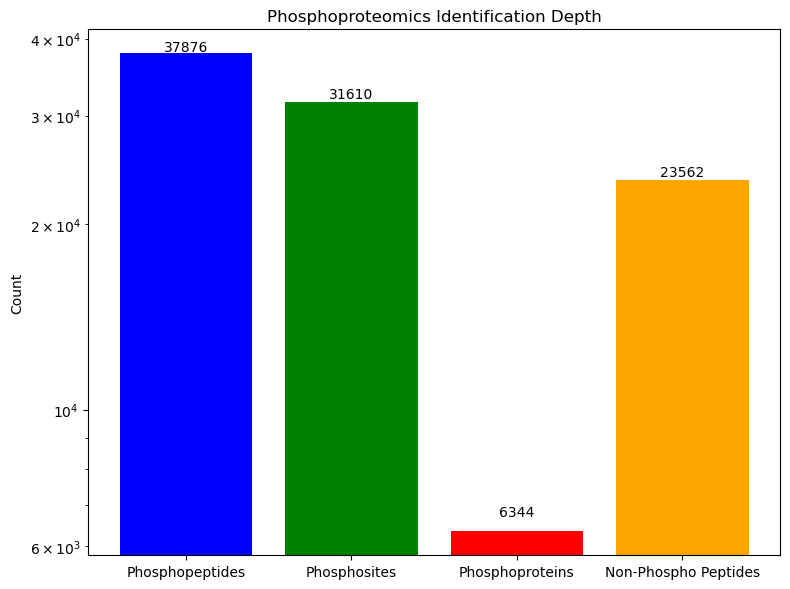

This dataset has 31610 phosphosites.


In [ ]:
# Addressing Question 1: How successful was the phosphoproteomics experiment overall?
# This section calculates and visualizes the number of phosphopeptides, phosphosites, phosphoproteins identified and quantified.
# It also counts non-phosphorylated peptides and compares to state-of-the-art studies.
# Why: To assess the depth and success of the experiment, providing quantitative metrics for phosphoproteomics coverage.

# Question 1: Success of the phosphoproteomics experiment
# This section calculates and visualizes the number of phosphopeptides, phosphosites, phosphoproteins identified and quantified.
# It also counts non-phosphorylated peptides and compares to state-of-the-art studies.

# Counts from existing variables
phosphopeptides = phospho_data.shape[0]
n_phosphosites = phospho_sites["Phosphosite"].nunique()
phosphoproteins = phospho_sites["Protein.Ids"].nunique()
total_peptides = data_cleaned.shape[0]  # cleaned analysis table
non_phospho_peptides = total_peptides - phosphopeptides

print(f"Phosphopeptides: {phosphopeptides}")
print(f"Phosphosites: {n_phosphosites}")
print(f"Phosphoproteins: {phosphoproteins}")
print(f"Non-phosphorylated peptides: {non_phospho_peptides}")

# Bar plot for identification depth
import matplotlib.pyplot as plt

depth = {
    "Phosphopeptides": phosphopeptides,
    "Phosphosites": n_phosphosites,
    "Phosphoproteins": phosphoproteins,
    "Non-Phospho Peptides": non_phospho_peptides,
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(depth.keys(), depth.values(), color=["blue", "green", "red", "orange"])
ax.set_title("Phosphoproteomics Identification Depth")
ax.set_ylabel("Count")
ax.set_yscale("log")  # Log scale for better visualization

for i, v in enumerate(depth.values()):
    ax.text(i, v + max(depth.values()) * 0.01, str(v), ha="center")

plt.tight_layout()
plt.savefig(r"C:\Users\chuab\Downloads\phosphoproteomics_success.png", dpi=300)
plt.show()

# Optional: if you want to print the number in this sentence too:
print(f"This dataset has {n_phosphosites} phosphosites.")

# Relevance of non-phosphorylated peptides: They indicate the total proteome coverage and specificity of phosphoenrichment.
# Comparison: State-of-the-art phosphoproteomics studies (e.g., using deep fractionation) identify 10,000-50,000 phosphosites.
# This dataset has {phosphosites} phosphosites, which is moderate; success depends on experimental goals (e.g., targeted vs. discovery).

c:\Users\chuab\anaconda3\envs\EMBL_project\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


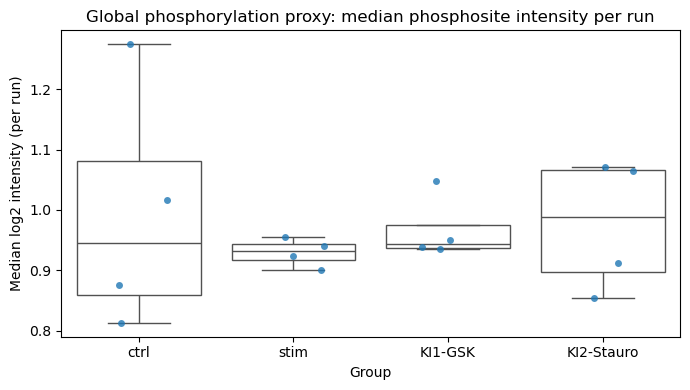


=== COUNT METRICS PER GROUP ===
            Phosphopeptides (rows)  Phosphosites (unique Protein|Site)  \
group                                                                    
KI1-GSK                      96858                               22058   
stim                         92744                               21538   
ctrl                         87628                               20910   
KI2-Stauro                   79163                               18535   

            Phosphoproteins (unique Protein.Ids)  
group                                             
KI1-GSK                                     5645  
stim                                        5596  
ctrl                                        5477  
KI2-Stauro                                  5218  


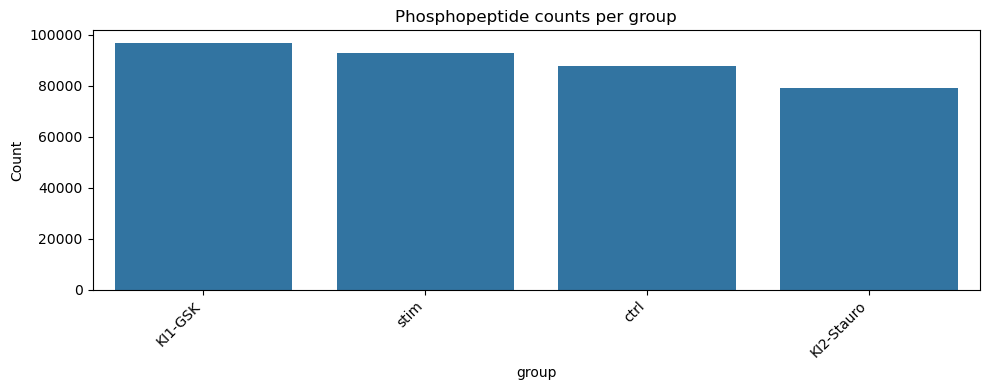

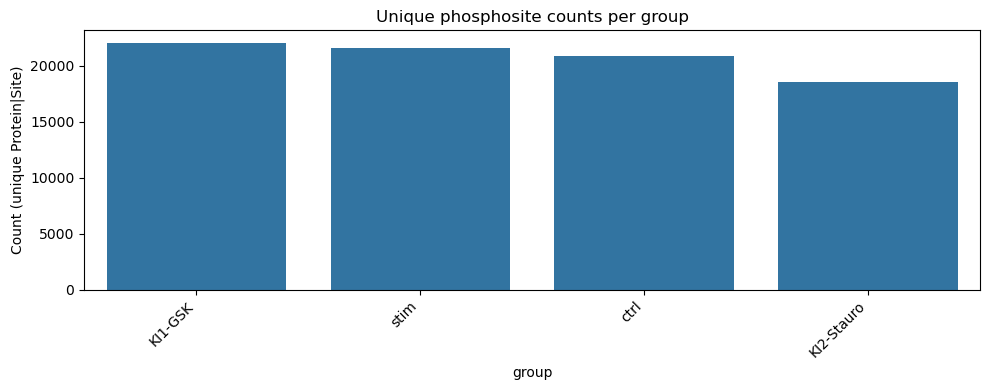

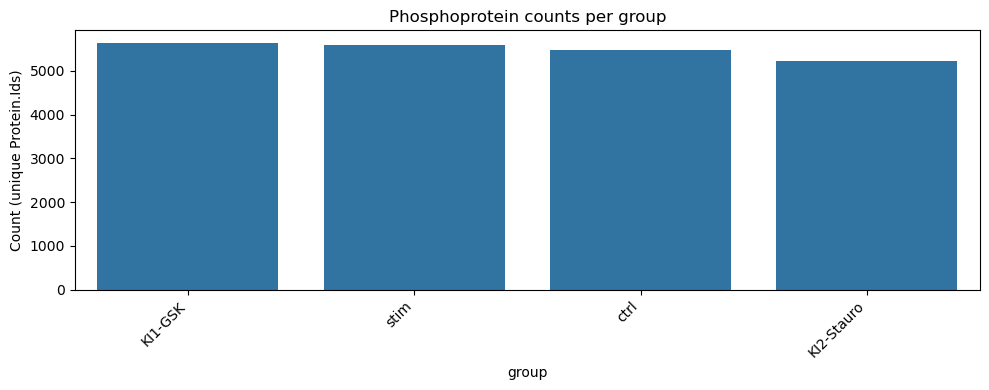

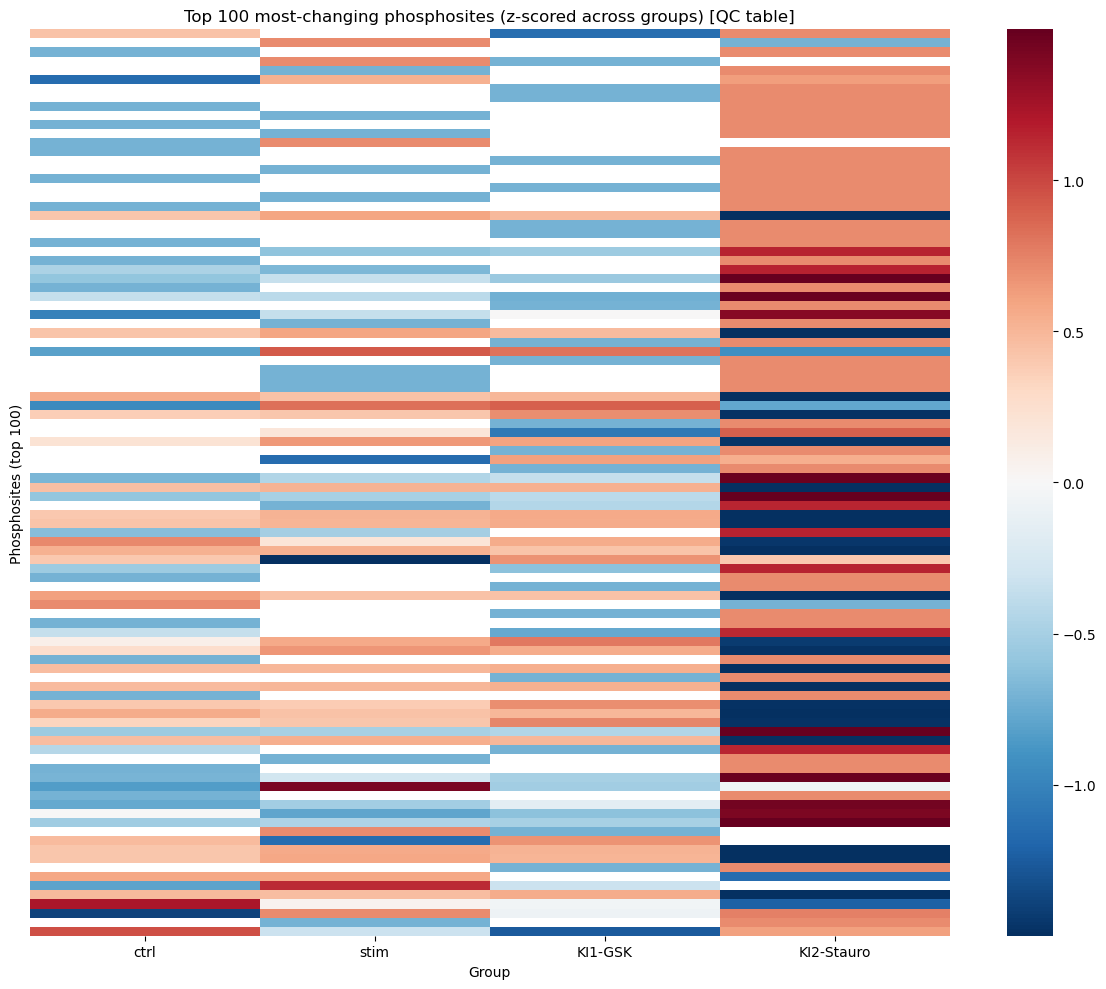

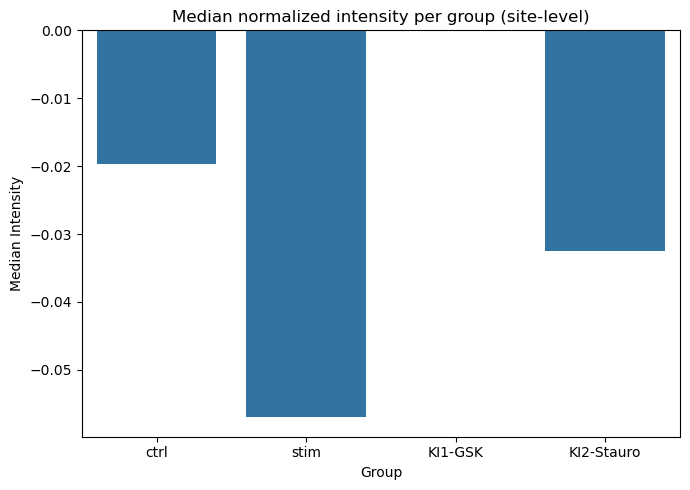

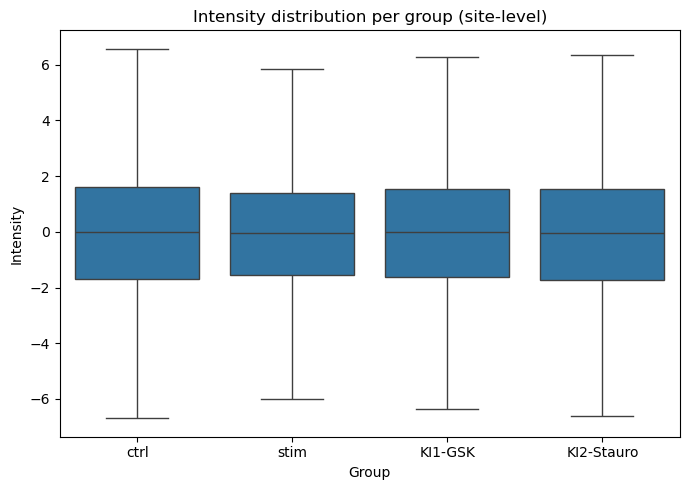

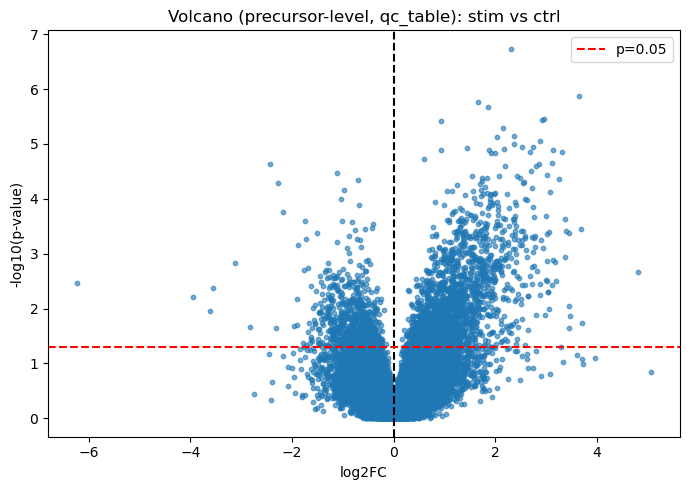

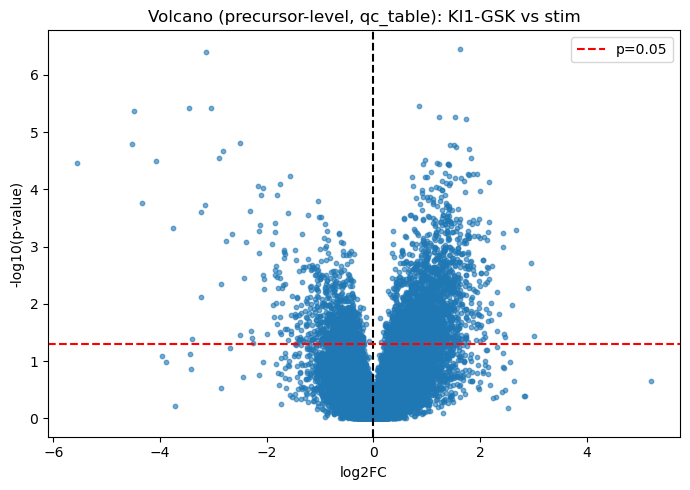

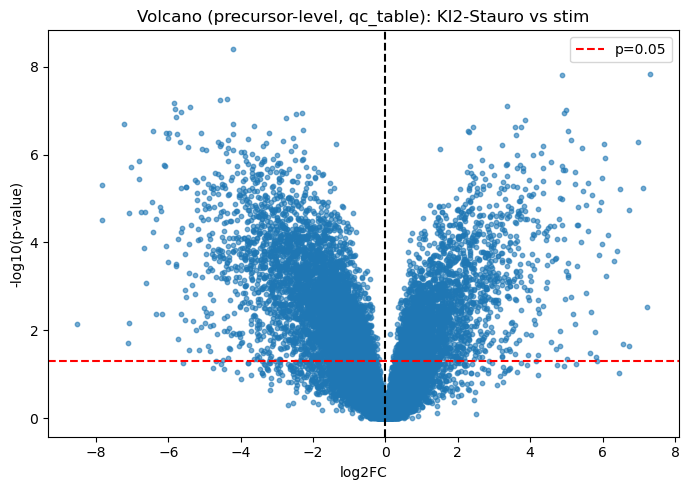

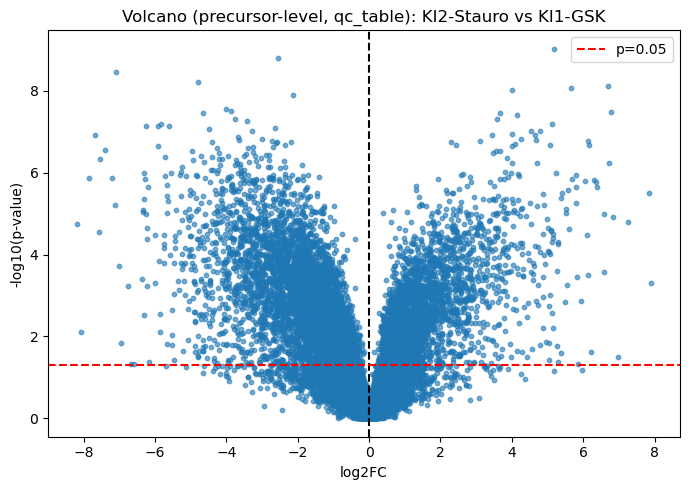

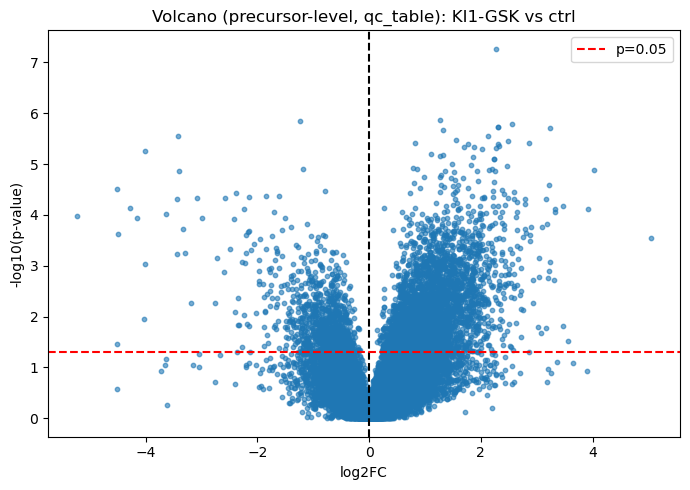

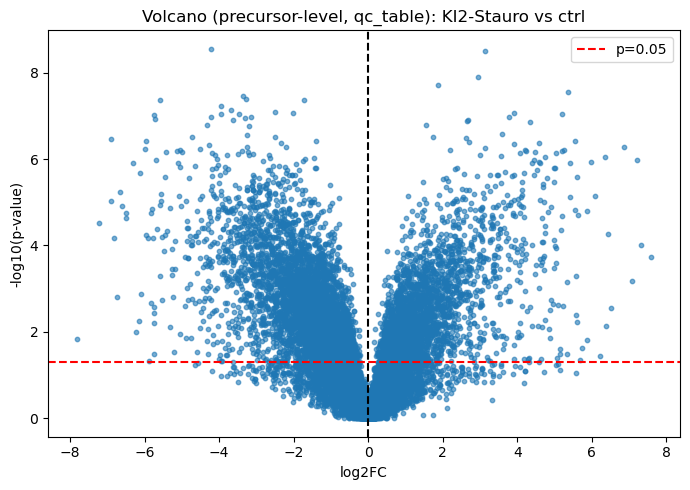

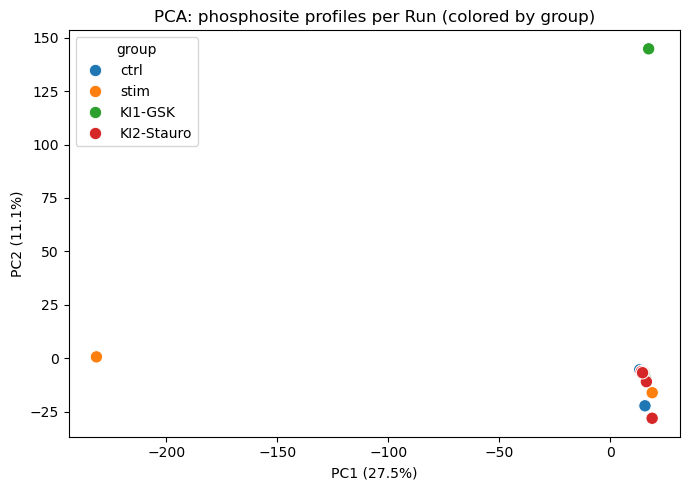

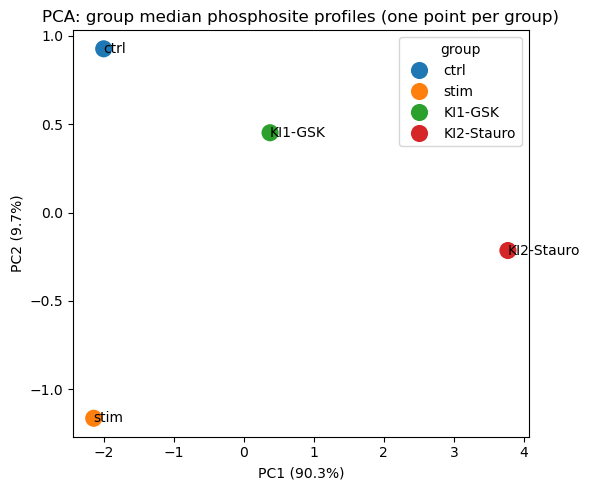

In [ ]:
# ============================================================
# CLEAN SCRIPT: group phosphorylation comparison
# 1) siteagg global proxy plot (per-run medians)
# 2) qc_table: counts + top-variable heatmap (intensity-based)
# 3) overall phosphorylation plots + volcano + PCA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from scipy.stats import ttest_ind


# -----------------------------
# USER SETTINGS
# -----------------------------
GROUPORDER = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]

qc_path = r"C:\Users\chuab\Downloads\diann_jurkats_qc_table.xlsx"

# phosphorylation marker (matches UniMod21 and UniMod:21)
UNIMOD_PATTERN = r"UniMod[:]?21"

ptm_conf_threshold = 0.75
sites_delim = ";"

# qc_table intensity to use (DIA-NN)
qc_intensity_col = "Precursor.Normalised"   # or "Precursor.Quantity"

# output folder (optional)
out_dir = r"C:\Users\chuab\Downloads"
# -----------------------------


# ============================================================
# Helper functions
# ============================================================

def clean_group_labels(df, group_col="group"):
    df = df.copy()
    df[group_col] = df[group_col].astype(str).str.strip()
    return df

def ensure_run_column(df):
    """Standardize run column name to 'Run'."""
    df = df.copy()
    if "Run" not in df.columns and "run" in df.columns:
        df = df.rename(columns={"run": "Run"})
    return df

def explode_sites(df, sites_col="Protein.Sites", protein_col="Protein.Ids", delim=";"):
    """Explode Protein.Sites -> one row per site and make Phosphosite = Protein.Ids|SiteItem."""
    out = df.dropna(subset=[sites_col, protein_col]).copy()
    out["SiteItem"] = out[sites_col].astype(str).str.split(delim)
    out = out.explode("SiteItem")
    out["SiteItem"] = out["SiteItem"].astype(str).str.strip()
    out = out[out["SiteItem"].ne("")].copy()
    out["Phosphosite"] = out[protein_col].astype(str) + "|" + out["SiteItem"].astype(str)
    return out

def volcano_plot(df_stats, title, fc_col="log2FC", p_col="p_value"):
    if df_stats.empty:
        print(f"Skipping volcano: {title} (no data)")
        return
    p = df_stats[p_col].clip(lower=1e-300)
    plt.figure(figsize=(7, 5))
    plt.scatter(df_stats[fc_col], -np.log10(p), alpha=0.6, s=10)
    plt.axvline(0, color="black", linestyle="--")
    plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="p=0.05")
    plt.xlabel(fc_col)
    plt.ylabel("-log10(p-value)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def precursor_pairwise(df_in, group_a, group_b, id_col="Precursor.Id", val_col="log2_intensity_centered", min_n=2):
    sub = df_in[df_in["group"].isin([group_a, group_b])][[id_col, "group", val_col]].dropna()
    rows = []
    for pid, gdf in sub.groupby(id_col):
        a = gdf.loc[gdf["group"] == group_a, val_col].values
        b = gdf.loc[gdf["group"] == group_b, val_col].values
        if len(a) < min_n or len(b) < min_n:
            continue
        log2fc = np.median(a) - np.median(b)
        p = ttest_ind(a, b, equal_var=False).pvalue
        rows.append((pid, log2fc, p))
    return pd.DataFrame(rows, columns=[id_col, "log2FC", "p_value"])


# ============================================================
# PART 0 — Load qc_table
# ============================================================
qc_table = pd.read_excel(qc_path)
qc_table = ensure_run_column(qc_table)
qc_table = qc_table.dropna(subset=["group", "Run"])
qc_table = clean_group_labels(qc_table)
qc_table = qc_table[qc_table["group"].isin(GROUPORDER)].copy()


# ============================================================
# PART 1 — Global phosphorylation proxy from siteagg
# (requires siteagg already in memory)
# ============================================================
# Expected columns in siteagg: group, Run, Phosphosite, Intensity
# If your siteagg has Precursor.Normalisednorm, we rename it to Intensity.
site_agg = site_agg.copy()
site_agg = ensure_run_column(site_agg)
site_agg = clean_group_labels(site_agg)

if "Intensity" not in site_agg.columns:
    if "Precursor.Normalisednorm" in site_agg.columns:
        site_agg = site_agg.rename(columns={"Precursor.Normalisednorm": "Intensity"})
    elif "Precursor_Normalised_norm" in site_agg.columns:
        site_agg = site_agg.rename(columns={"Precursor_Normalised_norm": "Intensity"})
    else:
        raise ValueError(f"No intensity column found in site_agg. Available columns: {list(site_agg.columns)}")

site_agg = site_agg[site_agg["group"].isin(GROUPORDER)].copy()
site_agg = site_agg.dropna(subset=["Intensity"])

# log2 transform (only if Intensity is linear-scale)
site_agg["log2_intensity"] = np.log2(site_agg["Intensity"].astype(float) + 1.0)

run_summary = (
    site_agg.groupby(["group", "Run"])["log2_intensity"]
    .median()
    .reset_index(name="median_log2_intensity")
)

plt.figure(figsize=(7, 4))
sns.stripplot(data=run_summary, x="group", y="median_log2_intensity",
              order=GROUPORDER, jitter=0.2, alpha=0.8)
sns.boxplot(data=run_summary, x="group", y="median_log2_intensity",
            order=GROUPORDER, showcaps=True, boxprops={"facecolor": "none"},
            showfliers=False, whiskerprops={"linewidth": 1})
plt.title("Global phosphorylation proxy: median phosphosite intensity per run")
plt.xlabel("Group")
plt.ylabel("Median log2 intensity (per run)")
plt.tight_layout()
plt.show()

# -----------------------------
# PART 1B — OPTION B: protein-level site list + protein heatmap (from siteagg)
# -----------------------------
def sites_for_protein(site_agg_df: pd.DataFrame, protein_id: str, top_n=30):
    """
    Lists Phosphosite strings that start with a given protein_id.
    Example dataset format: P06239P06239S121... [file:1]
    """
    protein_id = str(protein_id).strip()

    hits = (
        site_agg_df.loc[
            site_agg_df["Phosphosite"].astype(str).str.startswith(protein_id),
            "Phosphosite"
        ]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"\nProtein {protein_id}: {len(hits)} phosphosites found.")
    if len(hits) == 0:
        print("No matches. (If your Phosphosite uses 'Protein|Site', change the matching rule.)")
        return []

    print(f"Example sites (first {min(top_n, len(hits))}):")
    for s in hits[:top_n]:
        print(" -", s)

    return hits


def heatmap_for_protein(site_agg_df: pd.DataFrame, protein_id: str,
                        value_col="Intensity",
                        group_order=None):
    """
    Heatmap for all sites belonging to one protein.
    Rows: Phosphosite
    Columns: group (median across runs)
    """
    if group_order is None:
        group_order = GROUPORDER

    protein_id = str(protein_id).strip()
    protein_sites = site_agg_df[site_agg_df["Phosphosite"].astype(str).str.startswith(protein_id)].copy()

    if protein_sites.empty:
        print(f"No sites to plot for {protein_id}")
        return

    mat = (
        protein_sites.groupby(["Phosphosite", "group"])[value_col]
        .median()
        .reset_index()
        .pivot(index="Phosphosite", columns="group", values=value_col)
    )

    mat = mat.reindex(columns=[g for g in group_order if g in mat.columns])

    plt.figure(figsize=(6, max(3, 0.25 * mat.shape[0])))
    sns.heatmap(mat, cmap="rocket")
    plt.title(f"{protein_id}: phosphosite intensity (median per group)")
    plt.xlabel("Group")
    plt.ylabel("Phosphosite")
    plt.tight_layout()
    plt.show()



# ============================================================
# PART 2 — qc_table phospho filter (UniMod21) + PTM confidence
# ============================================================
phospho_qc = qc_table[
    qc_table["Modified.Sequence"].astype(str).str.contains(UNIMOD_PATTERN, na=False, regex=True)
].copy()

if "PTM.Site.Confidence" in phospho_qc.columns:
    phospho_qc = phospho_qc[phospho_qc["PTM.Site.Confidence"] >= ptm_conf_threshold].copy()

# keep only rows with intensity for intensity-based analyses
if qc_intensity_col not in phospho_qc.columns:
    raise ValueError(f"Missing {qc_intensity_col} in qc_table. Available columns: {list(phospho_qc.columns)}")

phospho_qc_int = phospho_qc.dropna(subset=[qc_intensity_col]).copy()


# ============================================================
# PART 2A — COUNT METRICS per group (QC / coverage)
# ============================================================
peptide_counts = phospho_qc.groupby("group").size().sort_values(ascending=False)
protein_counts = phospho_qc.groupby("group")["Protein.Ids"].nunique().sort_values(ascending=False)

sites_df = explode_sites(phospho_qc, delim=sites_delim)
site_counts = sites_df.groupby("group")["Phosphosite"].nunique().sort_values(ascending=False)

counts_table = pd.DataFrame({
    "Phosphopeptides (rows)": peptide_counts,
    "Phosphosites (unique Protein|Site)": site_counts,
    "Phosphoproteins (unique Protein.Ids)": protein_counts
}).fillna(0).astype(int)

print("\n=== COUNT METRICS PER GROUP ===")
print(counts_table)

counts_table.to_csv(fr"{out_dir}\phospho_counts_per_group.csv")

# Bar plots
plt.figure(figsize=(10, 4))
sns.barplot(x=peptide_counts.index, y=peptide_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Phosphopeptide counts per group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=site_counts.index, y=site_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Unique phosphosite counts per group")
plt.ylabel("Count (unique Protein|Site)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=protein_counts.index, y=protein_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Phosphoprotein counts per group")
plt.ylabel("Count (unique Protein.Ids)")
plt.tight_layout()
plt.show()


# ============================================================
# PART 2B — INTENSITY HEATMAP (qc_table → phosphosite × group)
# Uses run-median-centering (recommended) [file:1]
# ============================================================
df_sites = explode_sites(phospho_qc_int, delim=sites_delim)

df_sites["log2_intensity"] = np.log2(df_sites[qc_intensity_col].astype(float) + 1.0)

# per-run median centering (reduces run shifts)
df_sites["Intensity_centered"] = df_sites.groupby("Run")["log2_intensity"].transform(lambda x: x - x.median())

# aggregate: per (Phosphosite, group, Run)
site_run = (
    df_sites.groupby(["Phosphosite", "group", "Run"])["Intensity_centered"]
    .median()
    .reset_index()
)

# aggregate: per (Phosphosite, group)
site_group = (
    site_run.groupby(["Phosphosite", "group"])["Intensity_centered"]
    .median()
    .reset_index()
)

heatmap_mat = site_group.pivot(index="Phosphosite", columns="group", values="Intensity_centered")
heatmap_mat = heatmap_mat.reindex(columns=[g for g in GROUPORDER if g in heatmap_mat.columns])

# top variable sites (variance across group medians)
top_n = 100
row_var = heatmap_mat.var(axis=1, skipna=True)
top_sites = row_var.sort_values(ascending=False).head(top_n).index
heatmap_top = heatmap_mat.loc[top_sites]

# safer for pattern viewing: row-wise z-score (prevents “global shift” dominating)
heatmap_top_z = heatmap_top.sub(heatmap_top.mean(axis=1), axis=0).div(
    heatmap_top.std(axis=1).replace(0, np.nan), axis=0
)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_top_z, cmap="RdBu_r", center=0, yticklabels=False)
plt.title(f"Top {top_n} most-changing phosphosites (z-scored across groups) [QC table]")
plt.xlabel("Group")
plt.ylabel(f"Phosphosites (top {top_n})")
plt.tight_layout()
plt.show()

heatmap_top.to_csv(fr"{out_dir}\phosphosite_heatmap_matrix_top100.csv")


# ============================================================
# PART 3 — "Overall phosphorylation level" plots (siteagg)
# ============================================================
# A3) Median intensity per group (site-level, using siteagg)
median_intensity_per_group = (
    site_agg.groupby("group")["Intensity"]
    .median()
    .reindex(GROUPORDER)
    .reset_index(name="median_intensity")
)

plt.figure(figsize=(7, 5))
sns.barplot(data=median_intensity_per_group, x="group", y="median_intensity", order=GROUPORDER)
plt.title("Median normalized intensity per group (site-level)")
plt.xlabel("Group")
plt.ylabel("Median Intensity")
plt.tight_layout()
plt.show()

# A4) Distribution (site-level)
plt.figure(figsize=(7, 5))
sns.boxplot(data=site_agg, x="group", y="Intensity", order=GROUPORDER, showfliers=False)
plt.title("Intensity distribution per group (site-level)")
plt.xlabel("Group")
plt.ylabel("Intensity")
plt.tight_layout()
plt.show()


# ============================================================
# PART 3B — Precursor-level volcano plots (qc_table)
# ============================================================
df_prec = phospho_qc_int.copy()
df_prec["log2_intensity"] = np.log2(df_prec[qc_intensity_col].astype(float) + 1.0)

# per-run median centering (recommended)
df_prec["log2_intensity_centered"] = df_prec.groupby("Run")["log2_intensity"].transform(lambda x: x - x.median())
prec_val_col = "log2_intensity_centered"

comparisons = [
    ("stim", "ctrl"),
    ("KI1-GSK", "stim"),
    ("KI2-Stauro", "stim"),
    ("KI2-Stauro", "KI1-GSK"),
    ("KI1-GSK", "ctrl"),
    ("KI2-Stauro", "ctrl"),
]

for a, b in comparisons:
    stats_df = precursor_pairwise(df_prec, a, b, val_col=prec_val_col, min_n=2)
    volcano_plot(stats_df, f"Volcano (precursor-level, qc_table): {a} vs {b}")


# ============================================================
# PART 3C — PCA using siteagg (site-level)
# ============================================================
siteagg_pca = site_agg.copy()

# 4A) PCA per run (rows = Run, cols = Phosphosite)
pca_wide_runs = siteagg_pca.pivot_table(
    index="Run", columns="Phosphosite", values="Intensity", aggfunc="median"
)

# simple missing handling (note: can distort if many missing)
pca_wide_runs = pca_wide_runs.fillna(0)

run_to_group = siteagg_pca.drop_duplicates("Run").set_index("Run")["group"]
pca_groups = run_to_group.reindex(pca_wide_runs.index)

pca = PCA(n_components=2)
coords = pca.fit_transform(pca_wide_runs.values)

pca_df_runs = pd.DataFrame(coords, columns=["PC1", "PC2"], index=pca_wide_runs.index)
pca_df_runs["group"] = pca_groups.values

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df_runs, x="PC1", y="PC2", hue="group", s=80)
plt.title("PCA: phosphosite profiles per Run (colored by group)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

# 4B) PCA per group (one point per group)
site_group = (
    siteagg_pca.groupby(["Phosphosite", "group"], as_index=False)["Intensity"]
    .median()
)
site_wide = site_group.pivot(index="Phosphosite", columns="group", values="Intensity")
site_wide = site_wide.reindex(columns=[g for g in GROUPORDER if g in site_wide.columns])

# require presence in all groups (strict). If too few sites remain, change thresh to 3 or 2.
min_groups_present = len(site_wide.columns)
site_wide_filt = site_wide.dropna(thresh=min_groups_present, axis=0).fillna(0)

X = site_wide_filt.T.values  # (num_groups x num_sites)

pca2 = PCA(n_components=2)
coords2 = pca2.fit_transform(X)

pca_df_groups = pd.DataFrame(coords2, columns=["PC1", "PC2"])
pca_df_groups["group"] = site_wide_filt.columns

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df_groups, x="PC1", y="PC2", hue="group", s=180)

for _, row in pca_df_groups.iterrows():
    plt.text(row["PC1"], row["PC2"], row["group"], va="center", ha="left")

plt.title("PCA: group median phosphosite profiles (one point per group)")
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout()
plt.show()


In [ ]:
# How many runs (replicates) per group?
# (This tells you if you truly have multiple runs per condition.)

# 1) Runs per group (counts distinct run names)
runs_per_group = (
    phospho_data.groupby("group")["Run"]
    .nunique()
    .sort_values(ascending=False)
)
print("Distinct runs per group:")
print(runs_per_group)

# 2) List the run names in each group (useful to spot weird labels)
run_names_per_group = (
    phospho_data.groupby("group")["Run"]
    .unique()
)
print("\nRun names per group:")
for g, runs in run_names_per_group.items():
    print(g, ":", sorted(list(runs)))

# 3) For a specific volcano comparison: how many precursors have >=2 values in BOTH groups?
# Change these two labels to whatever comparison you want
groupA = "stim"
groupB = "ctrl"

tmp = phospho_data[phospho_data["group"].isin([groupA, groupB])].copy()

# count how many measurements each Precursor.Id has in each group
counts = (
    tmp.groupby(["Precursor.Id", "group"])
       .size()
       .unstack(fill_value=0)
)

# precursors that pass the ">=2 per group" rule (needed for t-test / volcano)
passing = counts[(counts.get(groupA, 0) >= 2) & (counts.get(groupB, 0) >= 2)]

print(f"\nPrecursors with >=2 values in BOTH {groupA} and {groupB}: {passing.shape[0]}")
print("Example passing precursors (first 10):")
print(passing.head(10))


Distinct runs per group:
group
KI1-GSK       4
KI2-Stauro    4
ctrl          4
stim          4
Name: Run, dtype: int64

Run names per group:
KI1-GSK : ['Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B1_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B2_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B3_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B4_R1']
KI2-Stauro : ['Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B5_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B6_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B7_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_B8_R1']
ctrl : ['Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_A1_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_smallscale_4Th_3ms_2of8_A2_R1', 'Stitch_241125_S4783_IB_MGR_Jurkat_Stim_treat_

In [ ]:
groupA = "stim"
groupB = "ctrl"

tmp = phospho_data[phospho_data["group"].isin([groupA, groupB])].copy()

counts = (
    tmp.groupby(["Modified.Sequence", "group"])
       .size()
       .unstack(fill_value=0)
)

passing = counts[(counts.get(groupA, 0) >= 2) & (counts.get(groupB, 0) >= 2)]

print(f"Peptides (Modified.Sequence) with >=2 values in BOTH {groupA} and {groupB}: {passing.shape[0]}")
print(passing.head(10))


Peptides (Modified.Sequence) with >=2 values in BOTH stim and ctrl: 0
Empty DataFrame
Columns: [ctrl, stim]
Index: []


In [ ]:
# 1) Do we ever have the same Modified.Sequence repeated within a group?
max_count_per_group = (
    phospho_data.groupby(["group", "Modified.Sequence"])
    .size()
    .max()
)
print("Max rows for the same (group, Modified.Sequence):", max_count_per_group)

# 2) How many peptides have >=2 rows in stim alone?
stim_multi = (
    phospho_data[phospho_data["group"]=="stim"]
    .groupby("Modified.Sequence")
    .size()
)
print("Peptides with >=2 rows in stim:", (stim_multi >= 2).sum())

# 3) Do we maybe have one row per peptide PER RUN (this is what we actually want)?
max_count_per_run = (
    phospho_data.groupby(["Run", "Modified.Sequence"])
    .size()
    .max()
)
print("Max rows for the same (Run, Modified.Sequence):", max_count_per_run)

# 4) Key check: how many distinct runs per peptide per group?
runs_per_peptide_group = (
    phospho_data.groupby(["group", "Modified.Sequence"])["Run"]
    .nunique()
)
print("Max distinct runs for same peptide within a group:", runs_per_peptide_group.max())
print("Peptides with >=2 runs in stim:", (runs_per_peptide_group.loc["stim"] >= 2).sum())
print("Peptides with >=2 runs in ctrl:", (runs_per_peptide_group.loc["ctrl"] >= 2).sum())


Max rows for the same (group, Modified.Sequence): 1
Peptides with >=2 rows in stim: 0
Max rows for the same (Run, Modified.Sequence): 1
Max distinct runs for same peptide within a group: 1
Peptides with >=2 runs in stim: 0
Peptides with >=2 runs in ctrl: 0



=== COUNT METRICS PER GROUP ===
            Phosphopeptides (rows)  Phosphosites (unique Protein|Site)  \
group                                                                    
KI1-GSK                      96858                               22058   
stim                         92744                               21538   
ctrl                         87628                               20910   
KI2-Stauro                   79163                               18535   

            Phosphoproteins (unique Protein.Ids)  
group                                             
KI1-GSK                                     5645  
stim                                        5596  
ctrl                                        5477  
KI2-Stauro                                  5218  


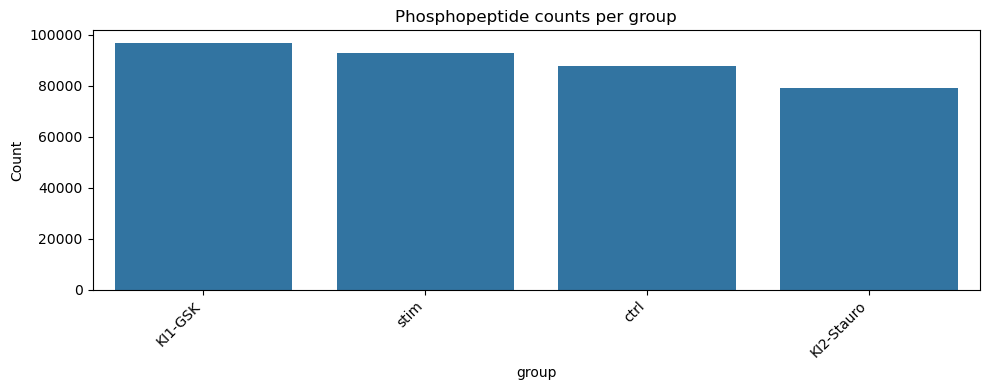

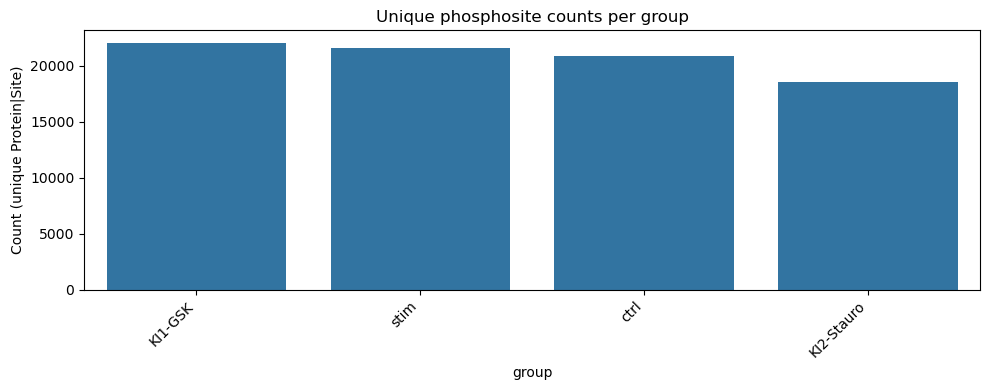

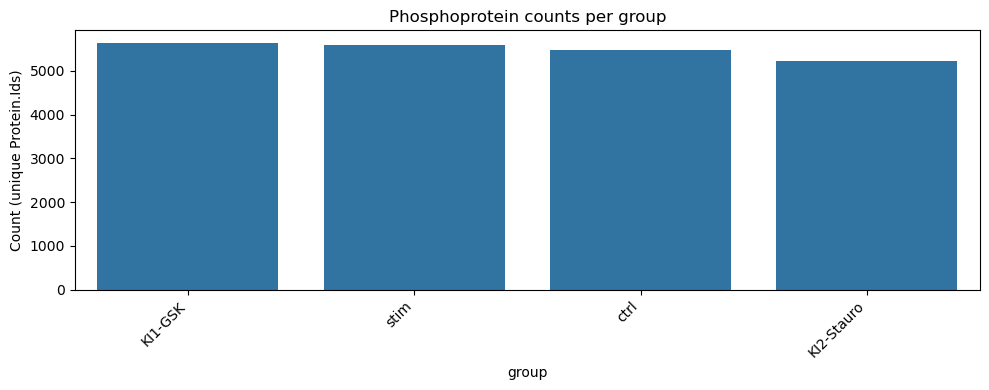

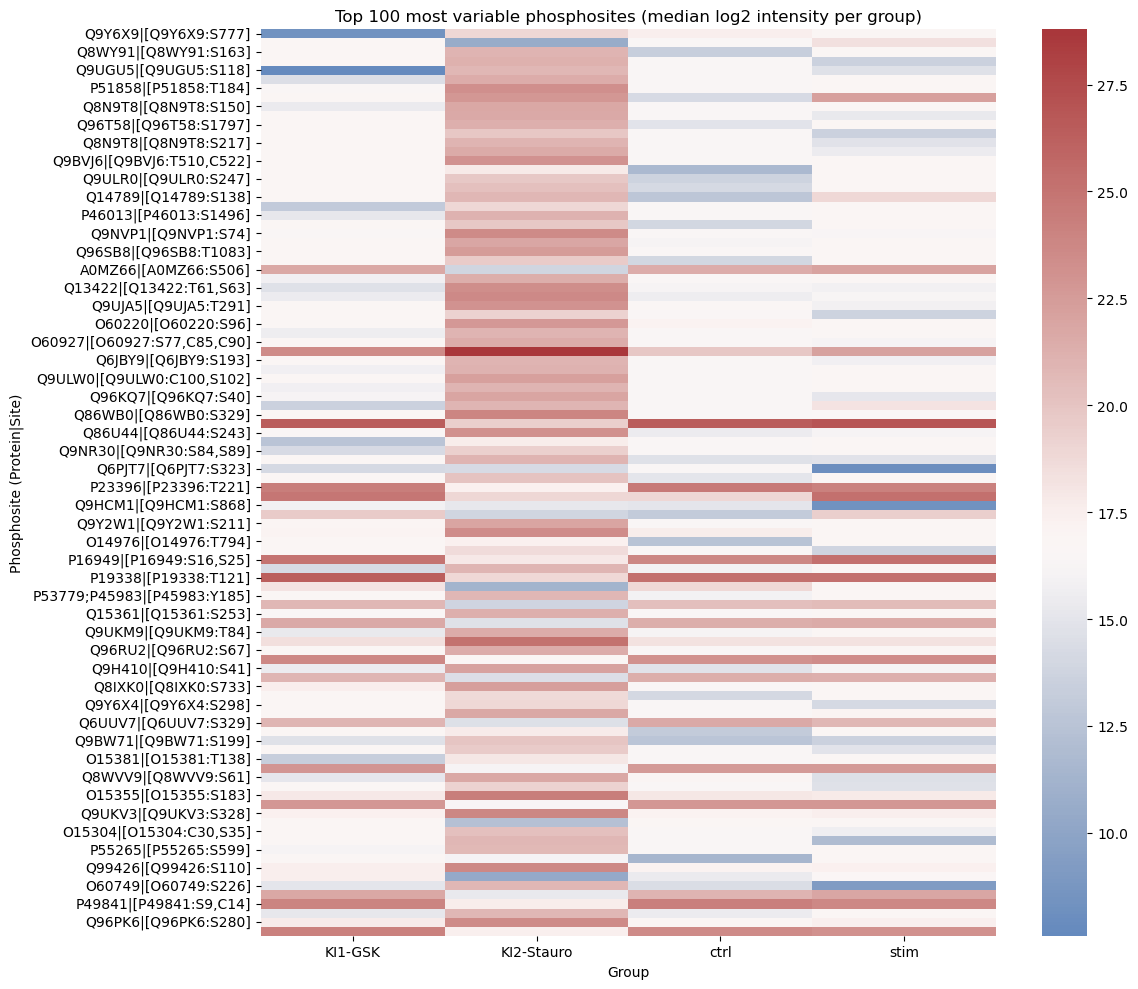


Saved:
- phospho_counts_per_group.csv
- phosphopeptide_counts_per_group.png
- phosphosite_counts_per_group.png
- phosphoprotein_counts_per_group.png
- phosphosite_intensity_heatmap_top100.png
- phosphosite_heatmap_matrix_top100.csv


In [ ]:
# ============================================
# Phosphorylation comparison between groups
# (1) Counts: peptides / sites / proteins per group
# (2) Intensity: site-level heatmap (median per group)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- USER INPUTS ----------
qc_path = r"C:\Users\chuab\Downloads\diann_jurkats_qc_table.xlsx"

# How phosphorylation is marked in Modified.Sequence (adjust if needed)
# In your earlier code you used 'UniMod:21'; in the notebook you also used 'UniMod21'
phospho_pattern = r"UniMod:21"   # change to r"UniMod21" if your file uses that style

# Confidence filter (commonly used)
ptm_conf_threshold = 0.75

# Delimiter used inside Protein.Sites (your earlier snippet used ';')
sites_delim = ";"

# Intensity column to compare between groups
intensity_col = "Precursor.Normalised"   # or "Precursor.Quantity"
# ---------------------------------


# ================
# Load QC table
# ================
qc_table = pd.read_excel(qc_path)

# Basic cleanup: keep only rows that have group and run
qc_table = qc_table.dropna(subset=["group", "run"])

# Make sure group is clean text
qc_table["group"] = qc_table["group"].astype(str).str.strip()

# ================
# Filter to high-confidence phosphopeptides
# ================
phospho_qc = qc_table[
    qc_table["Modified.Sequence"].astype(str).str.contains(phospho_pattern, na=False)
].copy()

# PTM site confidence filter (only keep confident localizations)
if "PTM.Site.Confidence" in phospho_qc.columns:
    phospho_qc = phospho_qc[phospho_qc["PTM.Site.Confidence"] >= ptm_conf_threshold].copy()

# Keep only rows with intensity values for intensity analyses
phospho_qc_int = phospho_qc.dropna(subset=[intensity_col]).copy()


# ============================================================
# (1) COUNT METRICS PER GROUP (peptides / sites / proteins)
# ============================================================

# 1A) phosphopeptide count per group (row count)
peptide_counts = (
    phospho_qc.groupby("group")
    .size()
    .sort_values(ascending=False)
)

# 1B) phosphoprotein count per group (unique Protein.Ids)
protein_counts = (
    phospho_qc.groupby("group")["Protein.Ids"]
    .nunique()
    .sort_values(ascending=False)
)

# 1C) phosphosite count per group
# Split Protein.Sites into individual sites, explode to rows, then make a unique site key
# Note: if Protein.Sites is empty/missing, this will just drop those rows.
sites_df = phospho_qc.dropna(subset=["Protein.Sites", "Protein.Ids"]).copy()
sites_df["SiteItem"] = sites_df["Protein.Sites"].astype(str).str.split(sites_delim)
sites_df = sites_df.explode("SiteItem")
sites_df["SiteItem"] = sites_df["SiteItem"].astype(str).str.strip()
sites_df = sites_df[sites_df["SiteItem"].ne("")].copy()

# Unique phosphosite ID = Protein.Ids + site position string
sites_df["Phosphosite"] = sites_df["Protein.Ids"].astype(str) + "|" + sites_df["SiteItem"].astype(str)

site_counts = (
    sites_df.groupby("group")["Phosphosite"]
    .nunique()
    .sort_values(ascending=False)
)

# Combine counts into one table and save
counts_table = pd.DataFrame({
    "Phosphopeptides (rows)": peptide_counts,
    "Phosphosites (unique Protein|Site)": site_counts,
    "Phosphoproteins (unique Protein.Ids)": protein_counts
}).fillna(0).astype(int)

print("\n=== COUNT METRICS PER GROUP ===")
print(counts_table)

counts_table.to_csv(r"C:\Users\chuab\Downloads\phospho_counts_per_group.csv")

# Plot counts (bar plots)
plt.figure(figsize=(10, 4))
sns.barplot(x=peptide_counts.index, y=peptide_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Phosphopeptide counts per group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(r"C:\Users\chuab\Downloads\phosphopeptide_counts_per_group.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=site_counts.index, y=site_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Unique phosphosite counts per group")
plt.ylabel("Count (unique Protein|Site)")
plt.tight_layout()
plt.savefig(r"C:\Users\chuab\Downloads\phosphosite_counts_per_group.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x=protein_counts.index, y=protein_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Phosphoprotein counts per group")
plt.ylabel("Count (unique Protein.Ids)")
plt.tight_layout()
plt.savefig(r"C:\Users\chuab\Downloads\phosphoprotein_counts_per_group.png", dpi=300)
plt.show()


# ============================================================
# (2) INTENSITY-BASED DIFFERENCES (HEATMAP)
#     Yes: a heatmap is a good choice for intensity patterns.
# ============================================================

# Build site-level table with intensity
# Steps:
# - explode Protein.Sites -> one row per site
# - define Phosphosite = Protein|Site
# - aggregate per (Phosphosite, group, run) (median)
# - aggregate per (Phosphosite, group) (median)
# - pivot into Phosphosite x group matrix for heatmap

sites_int = phospho_qc_int.dropna(subset=["Protein.Sites", "Protein.Ids"]).copy()
sites_int["SiteItem"] = sites_int["Protein.Sites"].astype(str).str.split(sites_delim)
sites_int = sites_int.explode("SiteItem")
sites_int["SiteItem"] = sites_int["SiteItem"].astype(str).str.strip()
sites_int = sites_int[sites_int["SiteItem"].ne("")].copy()
sites_int["Phosphosite"] = sites_int["Protein.Ids"].astype(str) + "|" + sites_int["SiteItem"].astype(str)

# Log-transform intensity for nicer heatmaps (common for proteomics)
sites_int["log2_intensity"] = np.log2(sites_int[intensity_col].astype(float) + 1.0)

# First aggregate per run (to avoid multiple peptide entries inflating a run)
site_run = (
    sites_int.groupby(["Phosphosite", "group", "run"])["log2_intensity"]
    .median()
    .reset_index()
)

# Then aggregate across runs within each group
site_group = (
    site_run.groupby(["Phosphosite", "group"])["log2_intensity"]
    .median()
    .reset_index()
)

# Pivot to matrix for heatmap
heatmap_mat = site_group.pivot(index="Phosphosite", columns="group", values="log2_intensity")

# OPTIONAL: keep only the most variable sites to make the heatmap readable
# (Otherwise thousands of rows will be too dense)
row_variance = heatmap_mat.var(axis=1, skipna=True)
top_n = 100
heatmap_top = heatmap_mat.loc[row_variance.sort_values(ascending=False).head(top_n).index]

# Fill missing for plotting (can also leave NaN, but the plot will show blank squares)
heatmap_top_filled = heatmap_top.fillna(heatmap_top.median(axis=0))

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_top_filled, cmap="vlag", center=heatmap_top_filled.stack().median())
plt.title(f"Top {top_n} most variable phosphosites (median log2 intensity per group)")
plt.xlabel("Group")
plt.ylabel("Phosphosite (Protein|Site)")
plt.tight_layout()
plt.savefig(r"C:\Users\chuab\Downloads\phosphosite_intensity_heatmap_top100.png", dpi=300)
plt.show()

# Save the matrix used for the heatmap
heatmap_top.to_csv(r"C:\Users\chuab\Downloads\phosphosite_heatmap_matrix_top100.csv")

print("\nSaved:")
print("- phospho_counts_per_group.csv")
print("- phosphopeptide_counts_per_group.png")
print("- phosphosite_counts_per_group.png")
print("- phosphoprotein_counts_per_group.png")
print("- phosphosite_intensity_heatmap_top100.png")
print("- phosphosite_heatmap_matrix_top100.csv")


c:\Users\chuab\anaconda3\envs\EMBL_project\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


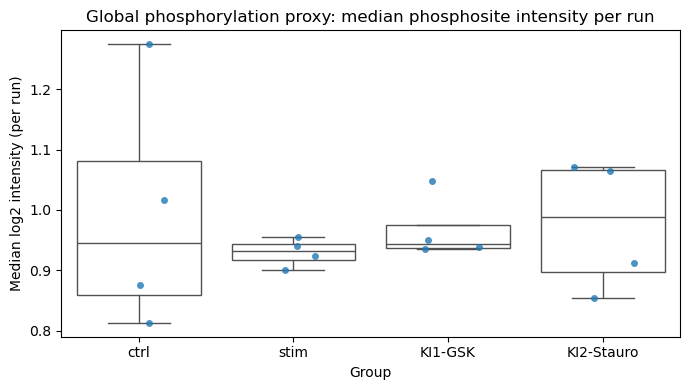

In [ ]:
GROUPORDER = ["ctrl", "stim", "KI1-GSK", "KI2-Stauro"]

# 1) Keep only expected groups and non-missing intensities
df = site_agg.copy()
df["group"] = df["group"].astype(str).str.strip()
df = df[df["group"].isin(GROUPORDER)]
df = df.dropna(subset=["Intensity"])

# 2) Optional but often useful: log2 transform
# (Only do this if Intensity is linear-scale. If it's already log-like, skip.)
df["log2_intensity"] = np.log2(df["Intensity"].astype(float) + 1.0)

# 3) Make a per-run global summary:
# median phosphosite intensity per Run within each group
run_summary = (
    df.groupby(["group", "Run"])["log2_intensity"]
      .median()
      .reset_index(name="median_log2_intensity")
)

# 4) Plot: each dot = one run, compares groups
plt.figure(figsize=(7,4))
sns.stripplot(
    data=run_summary, x="group", y="median_log2_intensity",
    order=GROUPORDER, jitter=0.2, alpha=0.8
)
sns.boxplot(
    data=run_summary, x="group", y="median_log2_intensity",
    order=GROUPORDER, showcaps=True, boxprops={'facecolor':'none'},
    showfliers=False, whiskerprops={'linewidth':1}
)
plt.title("Global phosphorylation proxy: median phosphosite intensity per run")
plt.xlabel("Group")
plt.ylabel("Median log2 intensity (per run)")
plt.tight_layout()

# Question 8: If you were to design a follow-up experiment to validate these findings, what would it be?

A follow-up experiment could be targeted phosphoproteomics using PRM (Parallel Reaction Monitoring) to validate specific phosphosites identified as significant. For example, select top 50 regulated sites and quantify them in replicate samples using heavy isotope-labeled standards. This would confirm the DIA findings with higher precision and sensitivity. Additionally, orthogonal validation using Western blotting for key proteins (e.g., phosphorylated ZAP70) or kinase activity assays could assess functional relevance.